# DICOM Annotation Pipeline — All Patients

Saves each patient as a single **HDF5 file** (`h5py`) instead of a compressed `.npz`.  
HDF5 is **10-20x faster** to write, supports chunked streaming reads, and is the standard format for ML medical imaging pipelines.

### Output structure per patient
```
dicom_pipeline_output/
  10006761/
    10006761_annotations.h5          <- pixel arrays + masks
    10006761_slice_summary.csv        <- one row per CT slice
  master_slice_summary.csv            <- all patients combined
```

### HDF5 layout
```
/slice_0042/
    pixels          int16  (512, 512)  — CT Hounsfield units
    z               float32 (1,)       — Z position in mm
    masks/
        rt_lung     bool    (512, 512)
        lt_lung     bool    (512, 512)
        heart       bool    (512, 512)
        breast      bool    (512, 512)
        ...
```

In [1]:
!pip install pydicom pylibjpeg pylibjpeg-libjpeg h5py --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 38.2 MB/s eta 0:00:00


In [2]:
import os, ast, warnings
import numpy as np
import pandas as pd
import pydicom
import h5py
from pydicom.uid import ExplicitVRLittleEndian
from pathlib import Path
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
print(f"pydicom : {pydicom.__version__}")
print(f"h5py    : {h5py.__version__}")

pydicom : 3.0.1
h5py    : 3.15.1


## 1 · Configuration

In [3]:
BASE_DIR   = Path("/kaggle/input/dicom-data/DICOMexported")
OUTPUT_DIR = Path("/kaggle/working/dicom_pipeline_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SAVE_H5        = True   # save HDF5 with pixel arrays + masks
SAVE_SLICE_CSV = True   # save per-patient slice summary CSV

# HDF5 chunk shape for pixel arrays — matches one 512x512 CT slice
# Adjust if your slices are a different size
H5_CHUNKS = (512, 512)

print(f"Input  : {BASE_DIR}")
print(f"Output : {OUTPUT_DIR}")

Input  : /kaggle/input/dicom-data/DICOMexported
Output : /kaggle/working/dicom_pipeline_output


## 2 · Helper Functions

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# 2a. Robust pixel decode — 4-attempt fallback chain
# ─────────────────────────────────────────────────────────────────────────────
def safe_pixel_array(ds):
    try:
        return ds.pixel_array.astype(np.int16)
    except Exception:
        pass
    try:
        if not hasattr(ds, 'file_meta'):
            ds.file_meta = pydicom.dataset.FileMetaDataset()
        ds.file_meta.TransferSyntaxUID = ExplicitVRLittleEndian
        ds.is_implicit_VR   = False
        ds.is_little_endian = True
        return ds.pixel_array.astype(np.int16)
    except Exception:
        pass
    try:
        if hasattr(ds, 'filename'):
            ds2 = pydicom.dcmread(str(ds.filename), force=True)
            if not hasattr(ds2, 'file_meta'):
                ds2.file_meta = pydicom.dataset.FileMetaDataset()
            ds2.file_meta.TransferSyntaxUID = ExplicitVRLittleEndian
            ds2.is_implicit_VR   = False
            ds2.is_little_endian = True
            return ds2.pixel_array.astype(np.int16)
    except Exception:
        pass
    try:
        rows  = int(ds.Rows)
        cols  = int(ds.Columns)
        bits  = int(ds.BitsAllocated)
        dtype = np.int16 if bits == 16 else np.uint8
        raw   = np.frombuffer(ds.PixelData, dtype=dtype)
        if raw.size >= rows * cols:
            return raw[:rows * cols].reshape(rows, cols).astype(np.int16)
    except Exception:
        pass
    return None


# ─────────────────────────────────────────────────────────────────────────────
# 2b. Read all files as DICOM (handles missing extensions)
# ─────────────────────────────────────────────────────────────────────────────
def read_all_dicom_files(patient_dir):
    results = []
    for f in patient_dir.iterdir():
        if not f.is_file():
            continue
        try:
            ds = pydicom.dcmread(str(f), force=True)
            ds.filename = str(f)
            if hasattr(ds, 'SOPInstanceUID'):
                results.append((f, ds))
        except Exception:
            continue
    return results


# ─────────────────────────────────────────────────────────────────────────────
# 2c. Split CT slices vs RT-Structure
# ─────────────────────────────────────────────────────────────────────────────
def split_ct_and_rtstruct(dicom_files):
    slices   = []
    rtstruct = None
    NON_CT   = {'RTDOSE', 'RTPLAN', 'RTRECORD', 'RTSTRUCT', 'REG', 'SEG'}
    for path, ds in dicom_files:
        modality = getattr(ds, 'Modality', '').strip().upper()
        if modality == 'RTSTRUCT' or hasattr(ds, 'StructureSetROISequence'):
            rtstruct = ds
            continue
        is_ct = (modality == 'CT' or modality == ''
                 or (modality not in NON_CT and hasattr(ds, 'PixelData')))
        if is_ct and hasattr(ds, 'PixelData'):
            z = 0.0
            if hasattr(ds, 'ImagePositionPatient'):
                try: z = float(ds.ImagePositionPatient[2])
                except: pass
            slices.append({'path': path, 'sop_uid': str(ds.SOPInstanceUID),
                           'z_pos': z, 'ds': ds})
    slices.sort(key=lambda x: x['z_pos'])
    return slices, rtstruct


# ─────────────────────────────────────────────────────────────────────────────
# 2d. Build SOP-UID -> contours lookup
# ─────────────────────────────────────────────────────────────────────────────
def build_sop_contour_map(rs_ds):
    roi_names = {}
    if hasattr(rs_ds, 'StructureSetROISequence'):
        for roi in rs_ds.StructureSetROISequence:
            roi_names[int(roi.ROINumber)] = str(roi.ROIName)
    sop_map = {}
    if not hasattr(rs_ds, 'ROIContourSequence'):
        return sop_map, roi_names
    for roi_contour in rs_ds.ROIContourSequence:
        roi_id = int(roi_contour.ReferencedROINumber)
        if not hasattr(roi_contour, 'ContourSequence'):
            continue
        for contour in roi_contour.ContourSequence:
            if not hasattr(contour, 'ContourImageSequence'):
                continue
            ref_uid = str(contour.ContourImageSequence[0].ReferencedSOPInstanceUID)
            pts = np.array(contour.ContourData, dtype=np.float32).reshape(-1, 3)
            sop_map.setdefault(ref_uid, {}).setdefault(roi_id, []).append(pts)
    return sop_map, roi_names


# ─────────────────────────────────────────────────────────────────────────────
# 2e. World (mm) -> pixel (col, row)
# ─────────────────────────────────────────────────────────────────────────────
def world_to_pixel(coords_mm, ds):
    origin  = np.array(ds.ImagePositionPatient,    dtype=np.float64)
    spacing = np.array(ds.PixelSpacing,            dtype=np.float64)
    cosines = np.array(ds.ImageOrientationPatient, dtype=np.float64)
    delta   = coords_mm.astype(np.float64) - origin
    col_idx = np.dot(delta, cosines[:3]) / spacing[1]
    row_idx = np.dot(delta, cosines[3:]) / spacing[0]
    return np.stack([col_idx, row_idx], axis=1).astype(np.int32)


# ─────────────────────────────────────────────────────────────────────────────
# 2f. Rasterise polygon -> binary mask
# ─────────────────────────────────────────────────────────────────────────────
def contour_to_mask(pixel_coords, rows, cols):
    mask = np.zeros((rows, cols), dtype=np.uint8)
    try:
        import cv2
        cv2.fillPoly(mask, [pixel_coords[:, [0, 1]].reshape(-1, 1, 2)], color=1)
    except ImportError:
        from matplotlib.path import Path as MplPath
        path = MplPath(pixel_coords[:, [1, 0]])
        rr, cc = np.mgrid[:rows, :cols]
        mask = path.contains_points(
            np.column_stack([rr.ravel(), cc.ravel()])
        ).reshape(rows, cols).astype(np.uint8)
    return mask.astype(bool)


print("Helper functions loaded.")

Helper functions loaded.


## 3 · Per-Patient Processing (HDF5 output)

In [5]:
def process_patient(patient_dir, output_dir, save_h5=True, save_csv=True):
    """
    Process one patient folder and write results to HDF5.

    Key difference from .npz approach:
      - Writes each slice to disk IMMEDIATELY via h5py, so nothing
        accumulates in RAM and no bulk compression step at the end.
      - Each slice group is written and flushed before moving to the next.
    """
    patient_id = patient_dir.name
    pat_out    = output_dir / patient_id
    pat_out.mkdir(parents=True, exist_ok=True)

    dicom_files = read_all_dicom_files(patient_dir)
    if not dicom_files:
        print(f"  [SKIP] No readable DICOM files in {patient_id}")
        return None

    slices, rs_ds = split_ct_and_rtstruct(dicom_files)
    if rs_ds is None:
        print(f"  [SKIP] No RT-Structure for {patient_id}")
        return None
    if not slices:
        print(f"  [SKIP] No CT slices for {patient_id}")
        return None

    sop_map, roi_names = build_sop_contour_map(rs_ds)

    records       = []
    px_fail_count = 0
    n_px_saved    = 0
    n_mask_saved  = 0

    h5_path = pat_out / f'{patient_id}_annotations.h5'

    # Open H5 file once; write each slice as we go — no RAM build-up
    with h5py.File(str(h5_path), 'w') as hf:

        # Store patient-level metadata
        hf.attrs['patient_id']  = patient_id
        hf.attrs['n_slices']    = len(slices)
        hf.attrs['roi_names']   = str(roi_names)

        for idx, slc in enumerate(slices):
            sop_uid  = slc['sop_uid']
            ds       = slc['ds']
            contours = sop_map.get(sop_uid, {})

            roi_ids_present   = list(contours.keys())
            roi_names_present = [roi_names.get(r, f'ROI_{r}') for r in roi_ids_present]
            n_pts = sum(sum(len(c) for c in cl) for cl in contours.values())
            has_geo = (hasattr(ds, 'ImagePositionPatient')
                       and hasattr(ds, 'PixelSpacing')
                       and hasattr(ds, 'ImageOrientationPatient'))

            records.append({
                'patient_id'           : patient_id,
                'slice_index'          : idx,
                'z_pos_mm'             : slc['z_pos'],
                'sop_uid'              : sop_uid,
                'n_rois_with_contours' : len(roi_ids_present),
                'roi_ids'              : str(roi_ids_present),
                'roi_names'            : str(roi_names_present),
                'n_contour_points'     : n_pts,
                'has_geometry_tags'    : has_geo,
                'ct_file'              : slc['path'].name,
            })

            # Only write slices that have contours
            if not (save_h5 and contours):
                continue

            # Decode pixel array
            pixel_arr = safe_pixel_array(ds)
            if pixel_arr is None:
                px_fail_count += 1
                continue

            rows, cols = pixel_arr.shape
            chunk = (min(rows, 512), min(cols, 512))

            # Create HDF5 group for this slice
            grp = hf.create_group(f'slice_{idx:04d}')
            grp.create_dataset('pixels', data=pixel_arr,
                               dtype=np.int16, chunks=chunk, compression=None)
            grp.create_dataset('z', data=np.array([slc['z_pos']], dtype=np.float32))
            grp.attrs['sop_uid']   = sop_uid
            grp.attrs['roi_names'] = str(roi_names_present)
            n_px_saved += 1

            # Build and write masks
            if has_geo:
                masks_grp = grp.create_group('masks')
                for roi_id, coord_list in contours.items():
                    roi_name      = roi_names.get(roi_id, f'ROI_{roi_id}')
                    combined_mask = np.zeros((rows, cols), dtype=bool)
                    for coords_mm in coord_list:
                        try:
                            px = world_to_pixel(coords_mm, ds)
                            px[:, 0] = np.clip(px[:, 0], 0, cols - 1)
                            px[:, 1] = np.clip(px[:, 1], 0, rows - 1)
                            combined_mask |= contour_to_mask(px, rows, cols)
                        except Exception:
                            pass
                    safe_name = roi_name.replace(' ', '_').replace('/', '_')
                    masks_grp.create_dataset(safe_name, data=combined_mask,
                                             dtype=bool, chunks=chunk, compression=None)
                    n_mask_saved += 1

            # Flush to disk after every slice — keeps memory low
            hf.flush()

    if px_fail_count > 0:
        print(f"  [INFO] {px_fail_count} slices: pixel_array decode failed.")

    df = pd.DataFrame(records)
    if save_csv:
        df.to_csv(pat_out / f'{patient_id}_slice_summary.csv', index=False)

    if save_h5:
        size_mb = h5_path.stat().st_size / 1e6
        print(f"  [H5  ] {n_px_saved} slices + {n_mask_saved} masks  →  "
              f"{h5_path.name}  ({size_mb:.1f} MB)")

    return df


print("process_patient() defined.")

process_patient() defined.


## 4 · Run Full Pipeline

In [6]:
patient_dirs  = sorted([p for p in BASE_DIR.iterdir() if p.is_dir()])
all_summaries = []
print(f"Found {len(patient_dirs)} patient folder(s)\n")

for patient_dir in tqdm(patient_dirs, desc='Processing patients'):
    print(f"\n-- Patient: {patient_dir.name} --")
    df = process_patient(
        patient_dir = patient_dir,
        output_dir  = OUTPUT_DIR,
        save_h5     = SAVE_H5,
        save_csv    = SAVE_SLICE_CSV,
    )
    if df is not None:
        annotated = (df['n_rois_with_contours'] > 0).sum()
        all_roi_names = set()
        for v in df['roi_names']:
            try: all_roi_names.update(ast.literal_eval(v))
            except: pass
        print(f"   {len(df)} slices / {annotated} annotated  |  ROIs: {sorted(all_roi_names)}")
        all_summaries.append(df)

if all_summaries:
    master_df = pd.concat(all_summaries, ignore_index=True)
    master_df.to_csv(OUTPUT_DIR / 'master_slice_summary.csv', index=False)
    print(f"\nMaster CSV saved — {len(master_df)} rows, {master_df['patient_id'].nunique()} patients")
else:
    master_df = pd.DataFrame()
    print("No data processed.")

Found 51 patient folder(s)



Processing patients:   0%|          | 0/51 [00:00<?, ?it/s]


-- Patient: 10006761 --
  [H5  ] 119 slices + 330 masks  →  10006761_annotations.h5  (150.5 MB)
   127 slices / 119 annotated  |  ROIs: ['breast', 'heart', 'isocenter', 'lt lung', 'patient', 'rt lung', 'scfpres', 'tanpres']

-- Patient: 10007494 --
  [H5  ] 135 slices + 385 masks  →  10007494_annotations.h5  (173.6 MB)
   140 slices / 135 annotated  |  ROIs: ['breast', 'heart', 'isocenter', 'lt lung', 'patient', 'rt lung', 'scfpres', 'tanpres']

-- Patient: 10008639 --
  [SKIP] No RT-Structure for 10008639

-- Patient: 10016037 --
  [H5  ] 130 slices + 303 masks  →  10016037_annotations.h5  (149.2 MB)
   136 slices / 130 annotated  |  ROIs: ['epres', 'heart', 'isocenter', 'lt lung', 'marker', 'patient', 'rt lung', 'scfpres', 'tanpres']

-- Patient: 10016826 --
  [H5  ] 120 slices + 328 masks  →  10016826_annotations.h5  (150.5 MB)
   126 slices / 120 annotated  |  ROIs: ['breast', 'epres', 'heart', 'isocenter', 'lt lung', 'patient', 'ps', 'rt lung']

-- Patient: 10020169 --
  [H5  ] 1

## 5 · Summary Statistics

In [7]:
if not master_df.empty:
    stats = (
        master_df
        .groupby('patient_id')
        .agg(
            total_slices       = ('slice_index',          'count'),
            annotated_slices   = ('n_rois_with_contours', lambda x: (x > 0).sum()),
            max_rois_per_slice = ('n_rois_with_contours', 'max'),
            total_contour_pts  = ('n_contour_points',     'sum'),
        ).reset_index()
    )
    display(stats)

,patient_id,total_slices,annotated_slices,max_rois_per_slice,total_contour_pts
0,10006761,127,119,5,123999
1,10007494,140,135,5,176936
2,10016037,136,130,5,93421
3,10016826,126,120,7,123523
4,10020169,150,141,7,157220
5,10027684,140,137,5,70175
6,10038547,146,140,6,111421
7,10040643,140,132,5,109741
8,10041089,146,139,6,90346
9,10041275,138,127,5,104577


## 6 · Visualise — All ROIs with Contour Outlines

In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from skimage import measure

SKIP_ROIS = {'patient', 'isocenter', 'isocenter2', 'iso2', 'iso3',
             'ISO3', 'newISO', 'ctmarker', 'marker', 'bolus'}

COLORS = [
    '#e6194b', '#3cb44b', '#4363d8', '#f58231',
    '#911eb4', '#42d4f4', '#f032e6', '#bfef45',
    '#fabed4', '#469990', '#dcbeff', '#fffac8',
]


def visualise_patient_h5(patient_id, output_dir, save_png=True):
    h5_path = output_dir / patient_id / f'{patient_id}_annotations.h5'
    if not h5_path.exists():
        print(f"  No .h5 for {patient_id}")
        return

    with h5py.File(str(h5_path), 'r') as hf:
        slice_keys = sorted(hf.keys())

        # Find slice with most clinical ROI masks
        best_key       = None
        best_roi_count = 0
        for sk in slice_keys:
            if 'masks' not in hf[sk]:
                continue
            clinical = [
                k for k in hf[sk]['masks'].keys()
                if k.replace('_', ' ') not in SKIP_ROIS
            ]
            if len(clinical) > best_roi_count:
                best_roi_count = len(clinical)
                best_key       = sk

        if best_key is None:
            print(f"  No clinical masks found for {patient_id}")
            return

        pixel_arr = hf[best_key]['pixels'][:]
        mask_names = sorted([
            k for k in hf[best_key]['masks'].keys()
            if k.replace('_', ' ') not in SKIP_ROIS
        ])
        masks = {name: hf[best_key]['masks'][name][:] for name in mask_names}

    # CT windowing — soft tissue
    WC, WW = 40, 400
    vmin, vmax = WC - WW // 2, WC + WW // 2

    fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(14, 7))
    fig.patch.set_facecolor('#1a1a2e')

    for ax in (ax_left, ax_right):
        ax.imshow(pixel_arr, cmap='gray', vmin=vmin, vmax=vmax, interpolation='bilinear')
        ax.axis('off')

    ax_left.set_title('Contour outlines', color='white', fontsize=11, pad=6)
    ax_right.set_title('Filled masks', color='white', fontsize=11, pad=6)

    legend_patches = []
    for i, (name, mask) in enumerate(masks.items()):
        label = name.replace('_', ' ')
        color = COLORS[i % len(COLORS)]
        mask  = mask.astype(np.uint8)

        contours = measure.find_contours(mask, level=0.5)
        for c in contours:
            ax_left.plot( c[:, 1], c[:, 0], color=color, linewidth=1.8)
            ax_right.plot(c[:, 1], c[:, 0], color=color, linewidth=1.0)

        rgba = np.zeros((*mask.shape, 4), dtype=np.float32)
        rgba[mask == 1, :3] = mcolors.to_rgb(color)
        rgba[mask == 1,  3] = 0.38
        ax_right.imshow(rgba, interpolation='none')

        legend_patches.append(mpatches.Patch(color=color, label=label))

    fig.legend(
        handles=legend_patches, loc='lower center',
        ncol=min(len(legend_patches), 6), framealpha=0.3,
        facecolor='#1a1a2e', edgecolor='white', labelcolor='white',
        fontsize=9, bbox_to_anchor=(0.5, 0.0),
    )
    fig.suptitle(
        f'Patient {patient_id}  —  {best_key}  ({best_roi_count} ROIs)',
        color='white', fontsize=13, y=1.01
    )
    plt.tight_layout()

    if save_png:
        out = output_dir / f'{patient_id}_viz.png'
        plt.savefig(str(out), dpi=130, bbox_inches='tight',
                    facecolor=fig.get_facecolor())
        print(f"  Saved -> {out.name}")

    plt.show()
    plt.close()


print("visualise_patient_h5() defined.")

visualise_patient_h5() defined.


  Saved -> 10006761_viz.png


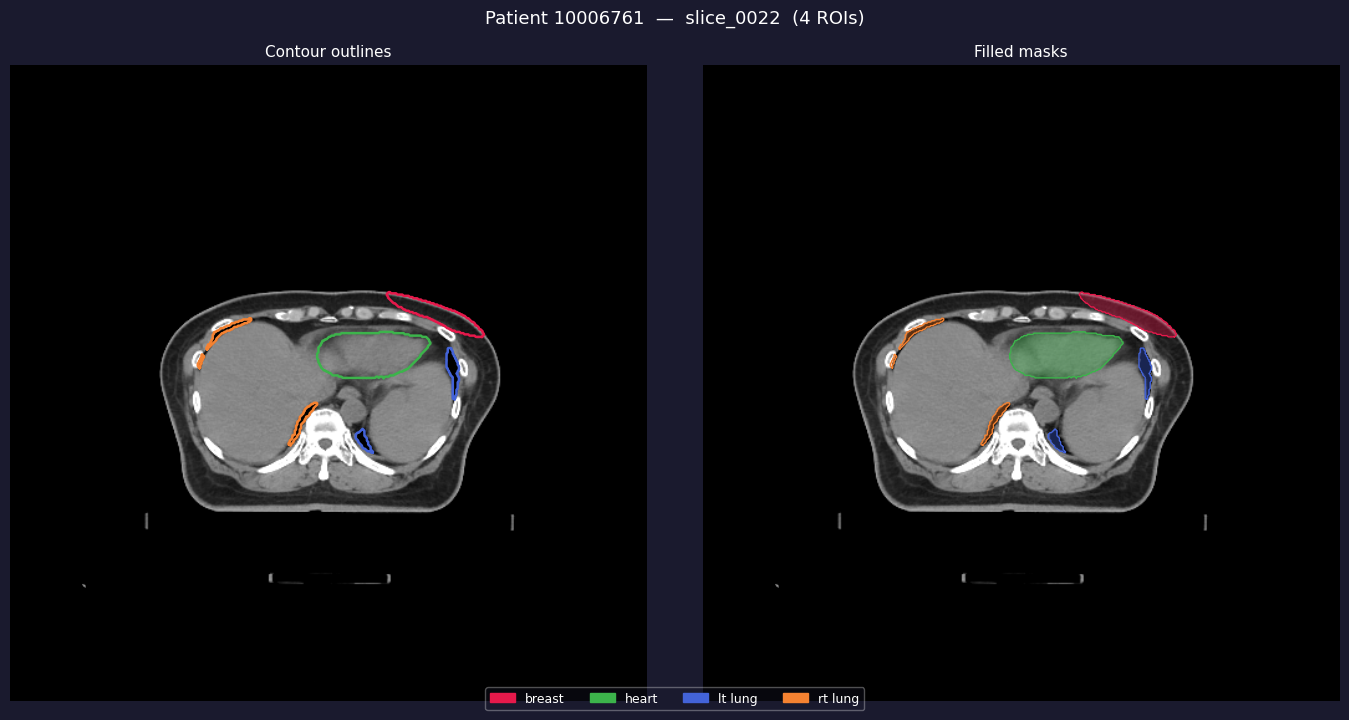

In [9]:
# Visualise a single patient quickly
visualise_patient_h5("10006761", OUTPUT_DIR, save_png=True)

Visualising:   0%|          | 0/51 [00:00<?, ?it/s]

  Saved -> 10006761_viz.png


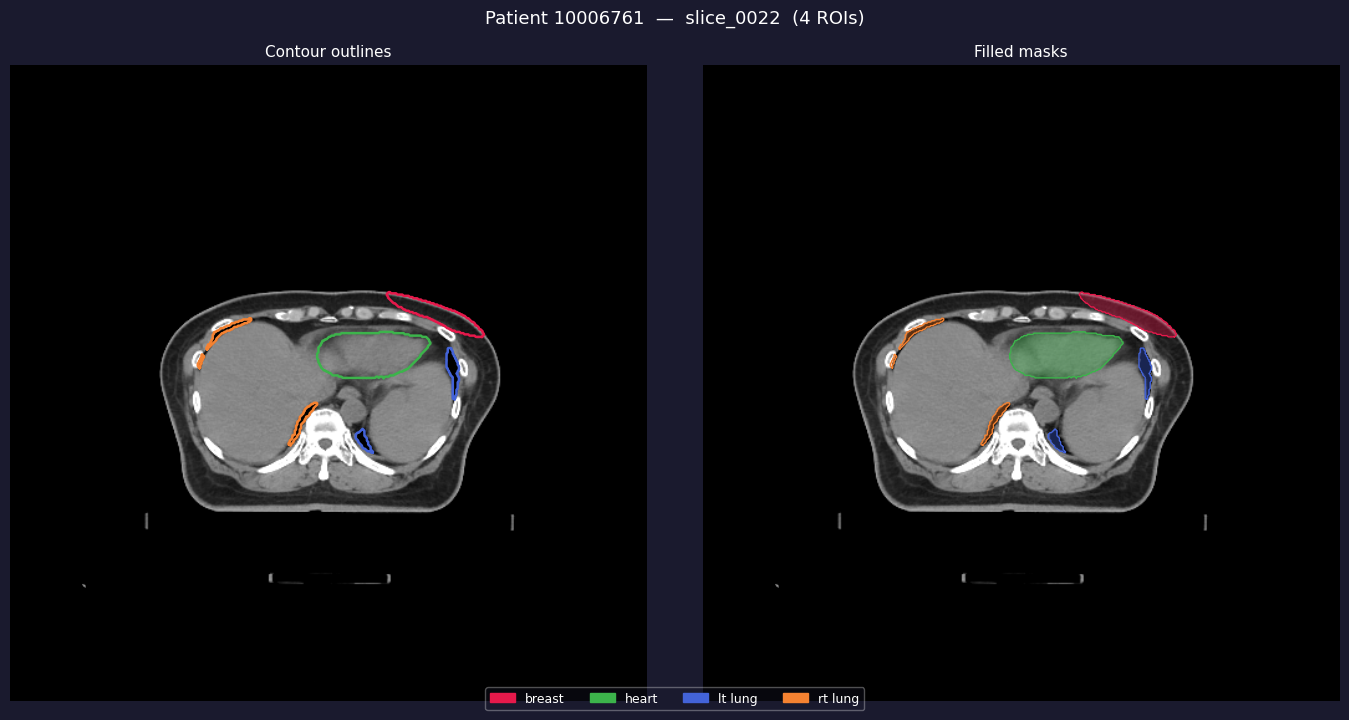

  Saved -> 10007494_viz.png


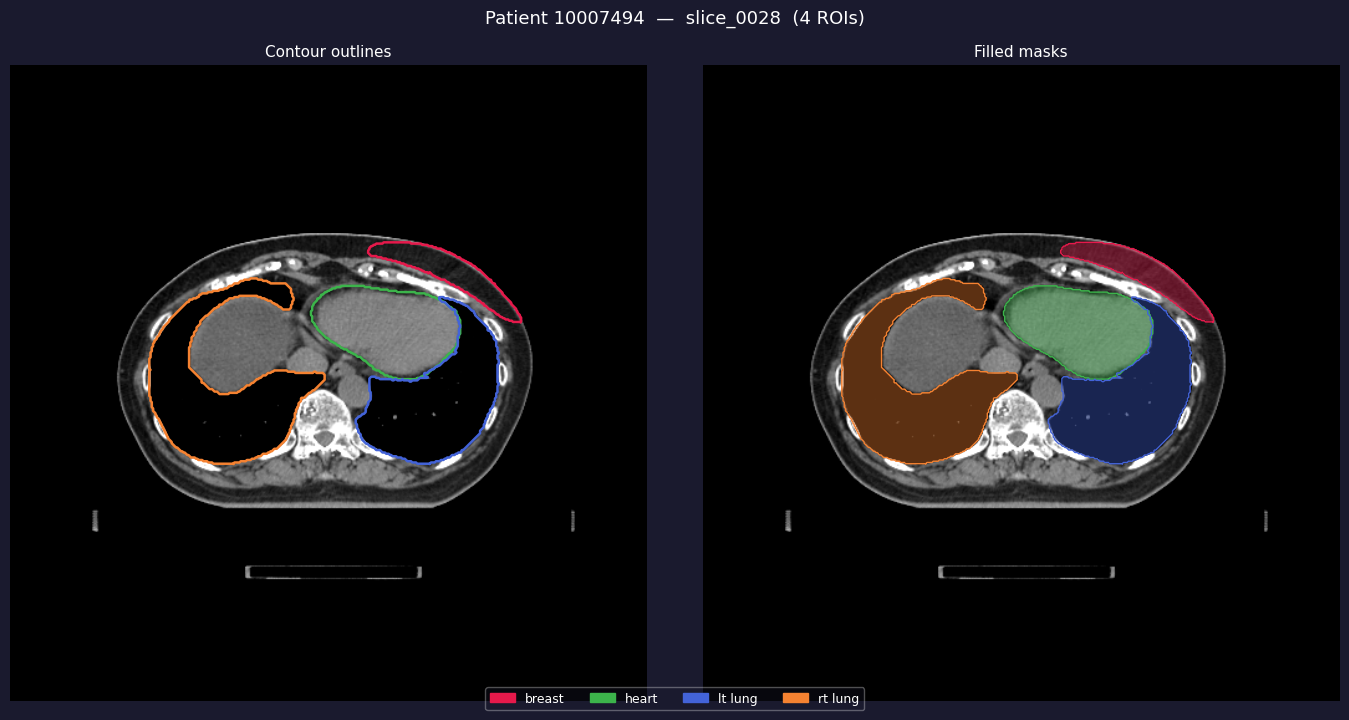

  No .h5 for 10008639
  Saved -> 10016037_viz.png


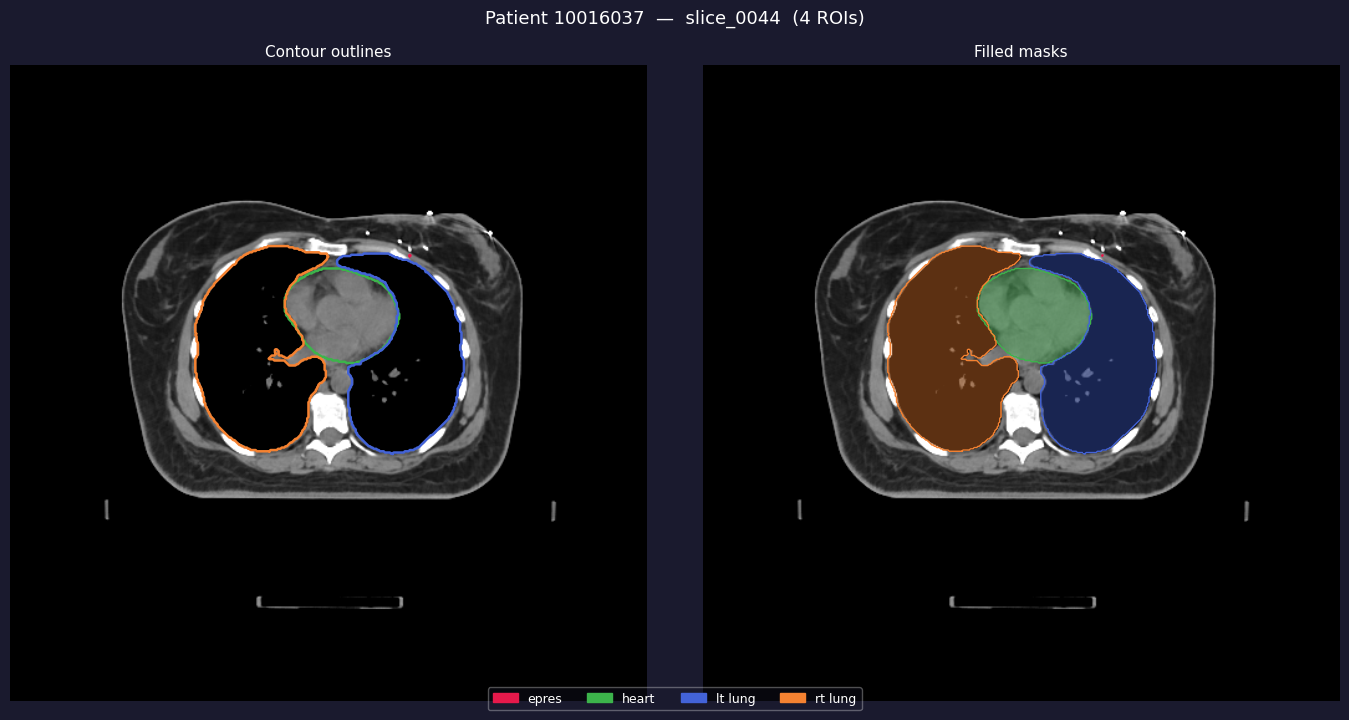

  Saved -> 10016826_viz.png


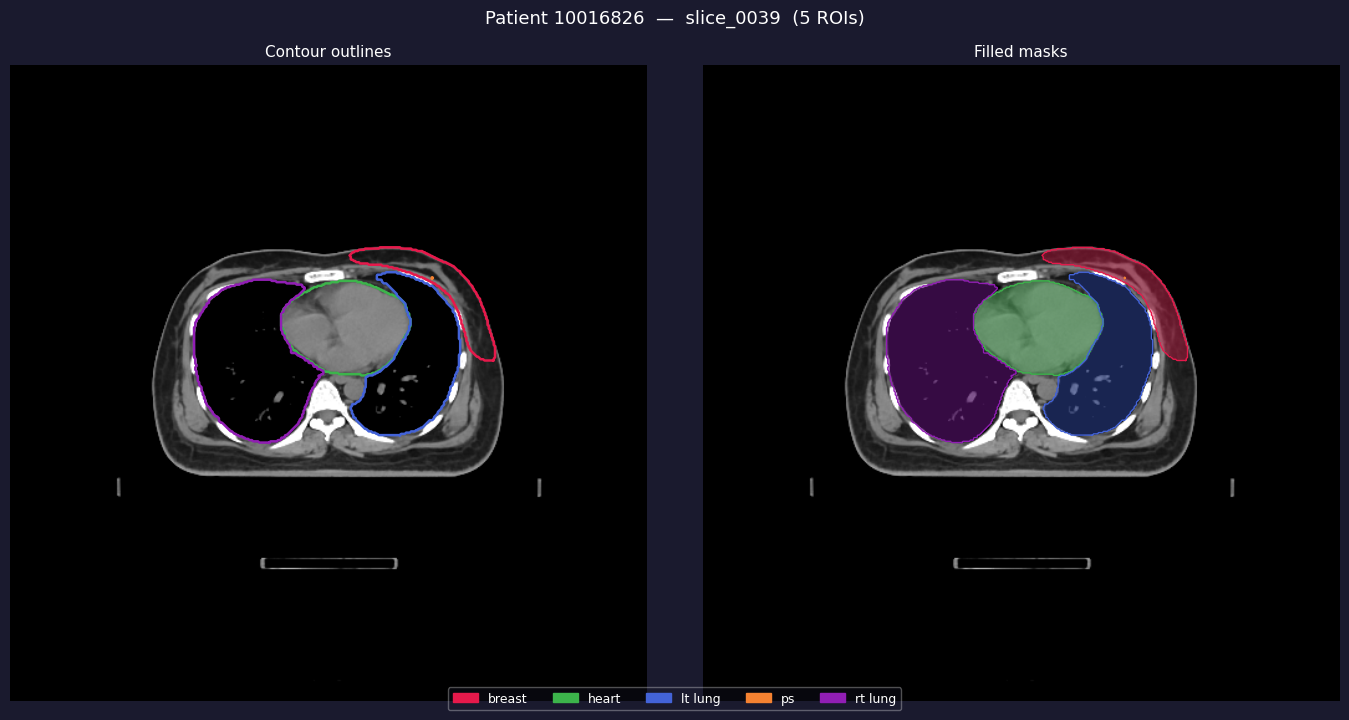

  Saved -> 10020169_viz.png


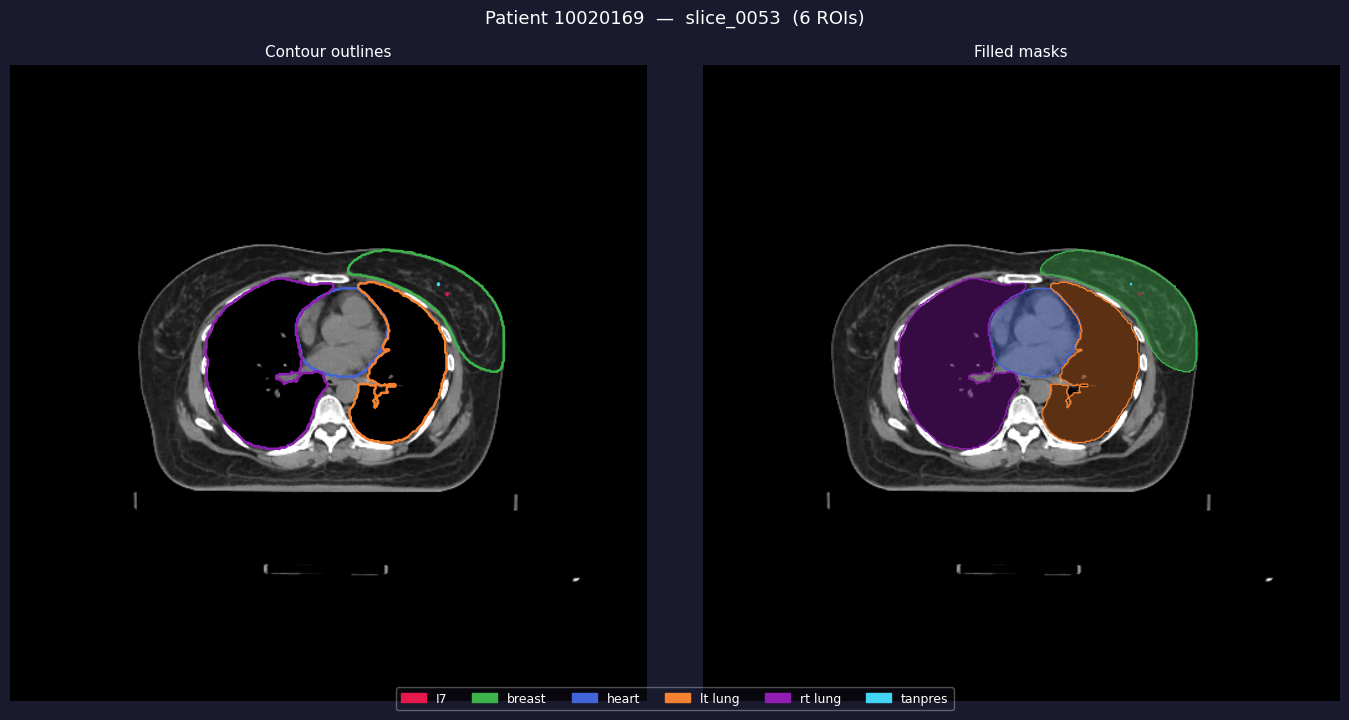

  Saved -> 10027684_viz.png


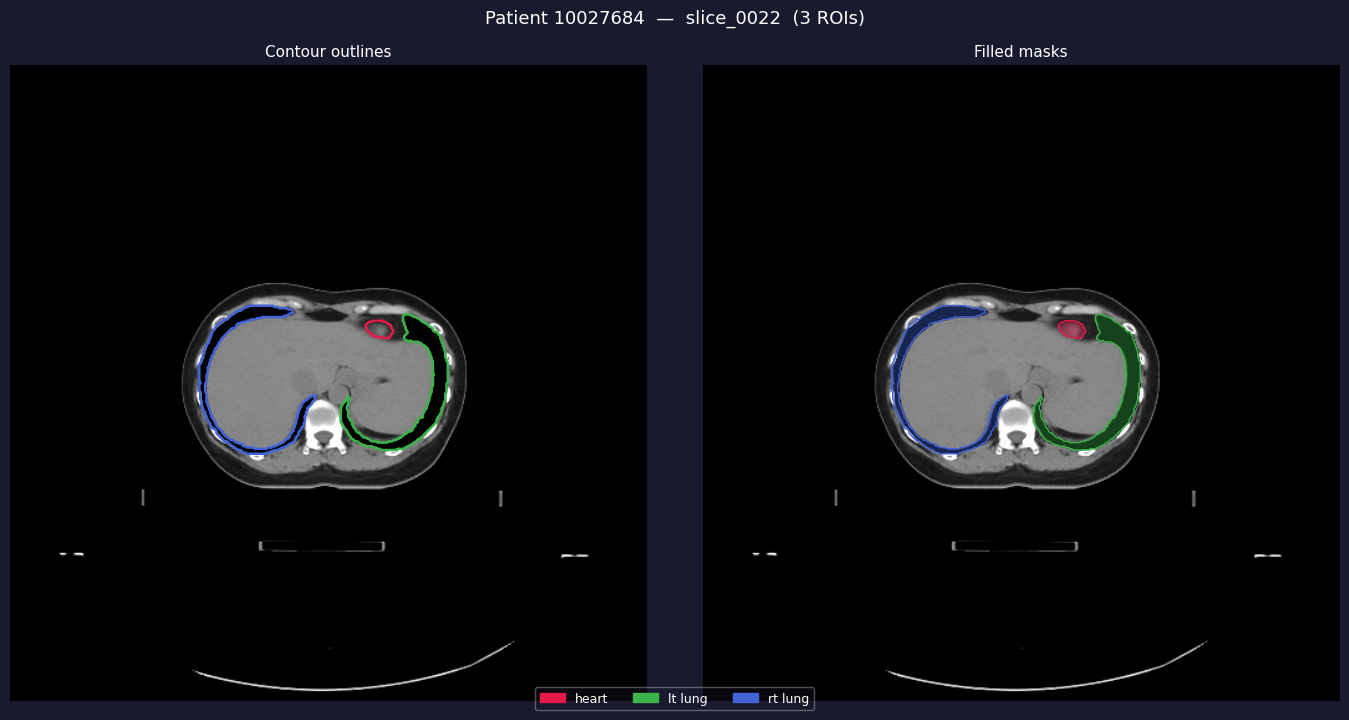

  Saved -> 10038547_viz.png


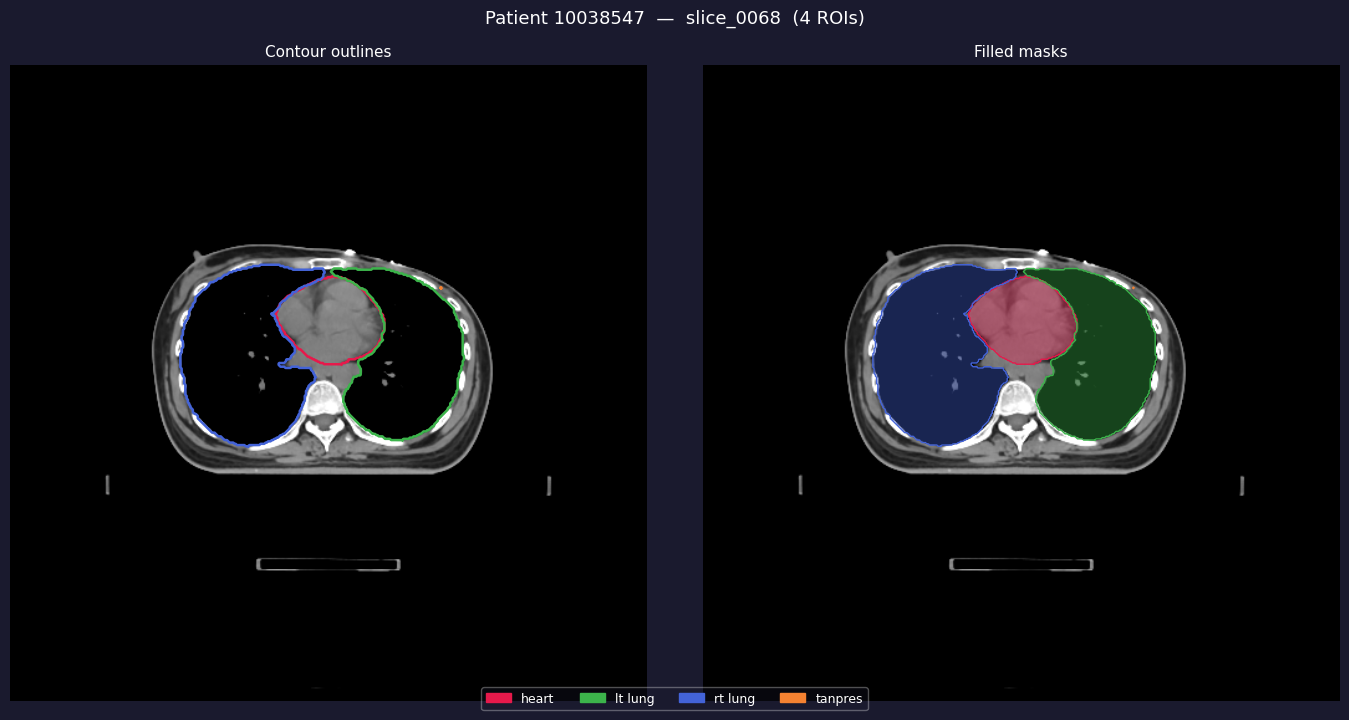

  Saved -> 10040643_viz.png


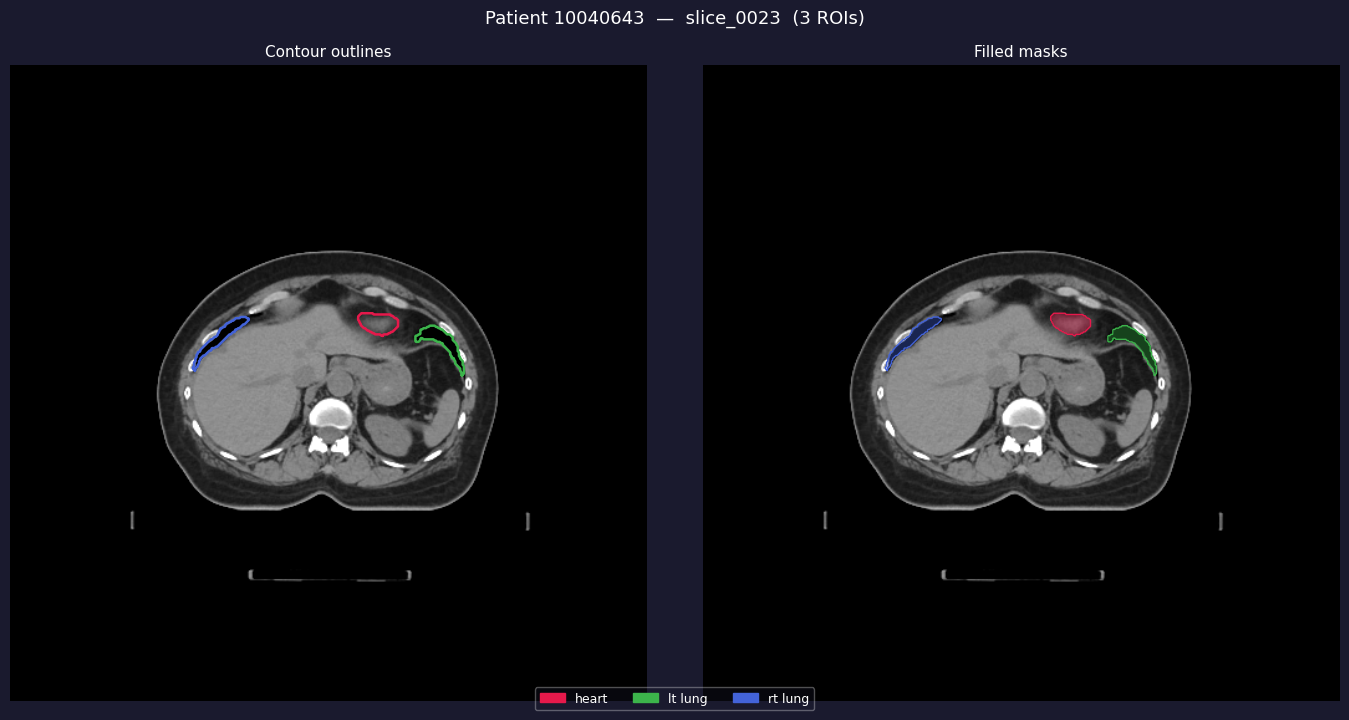

  Saved -> 10041089_viz.png


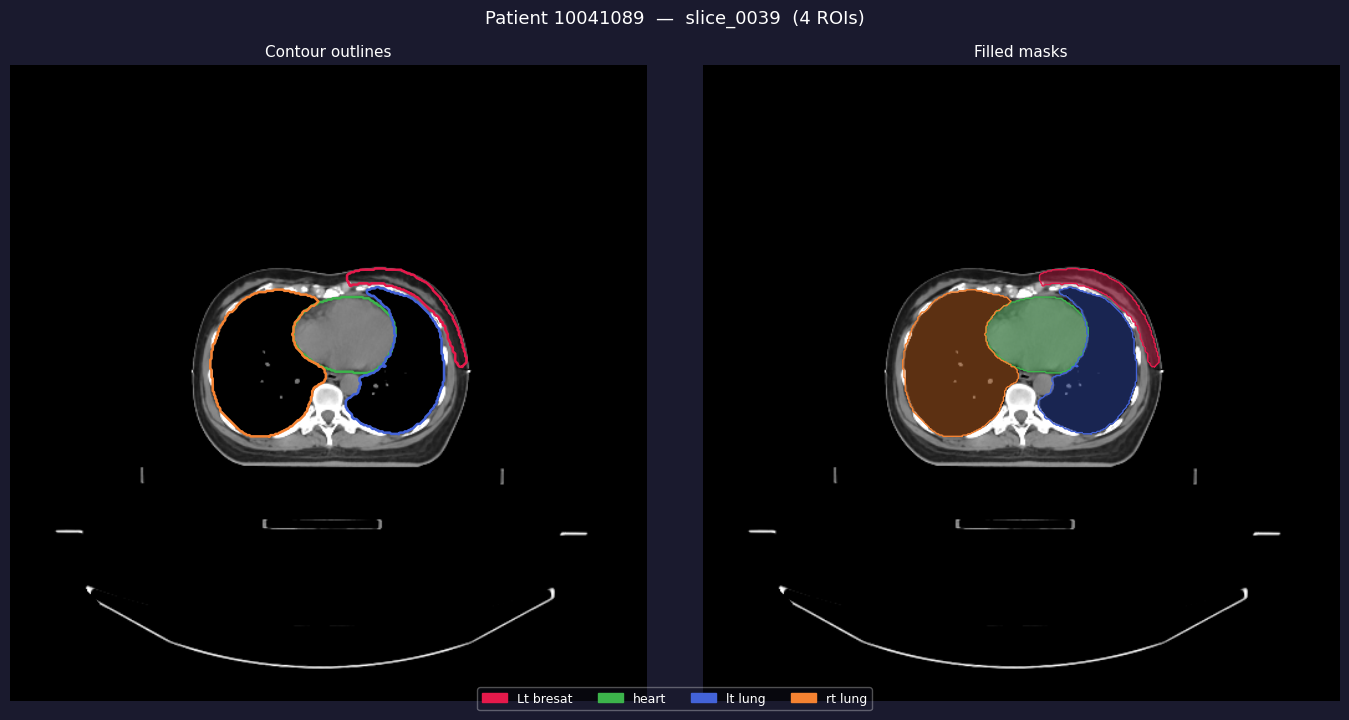

  Saved -> 10041275_viz.png


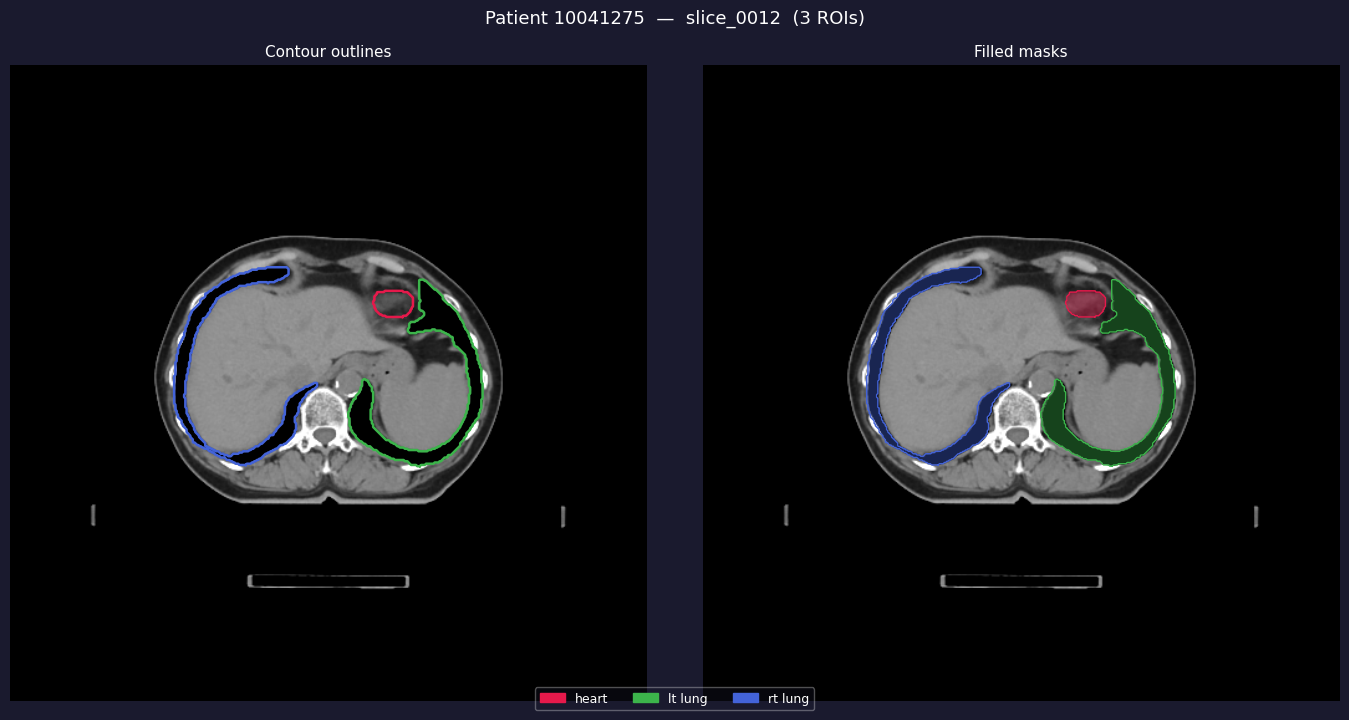

  Saved -> 10041651_viz.png


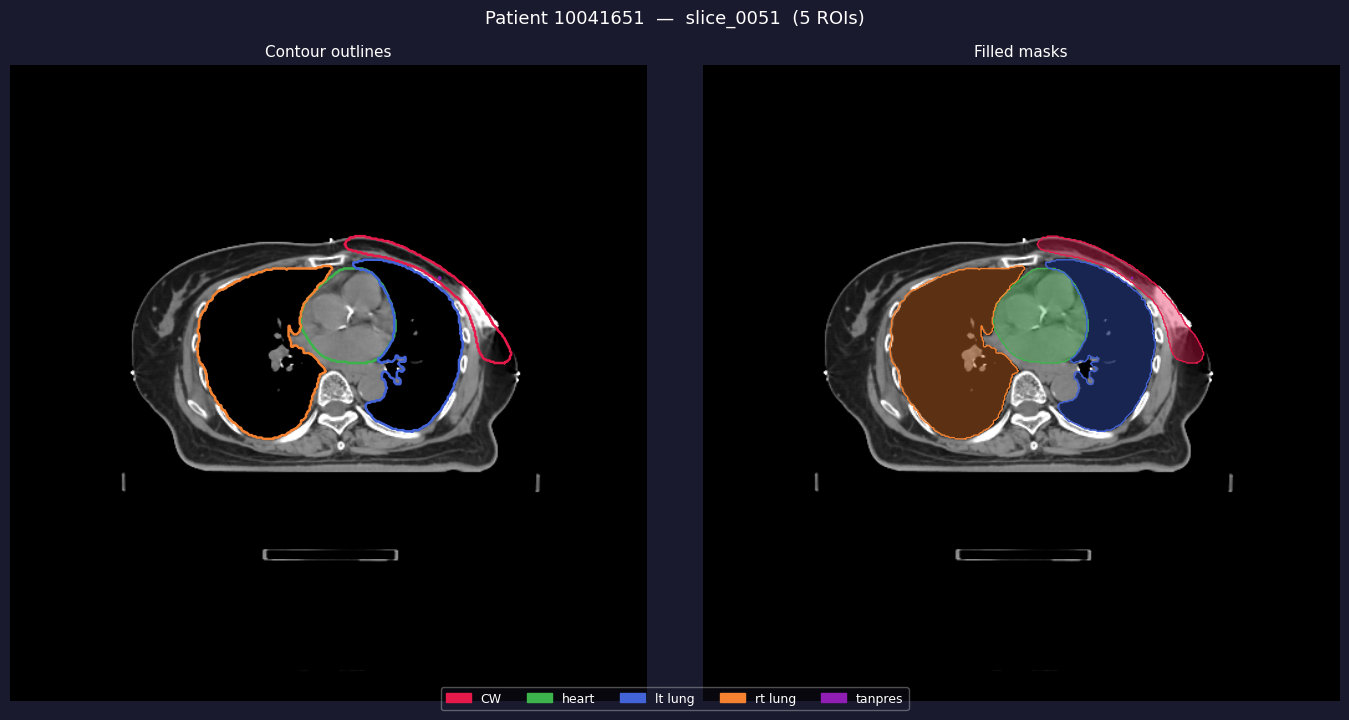

  Saved -> 10042244_viz.png


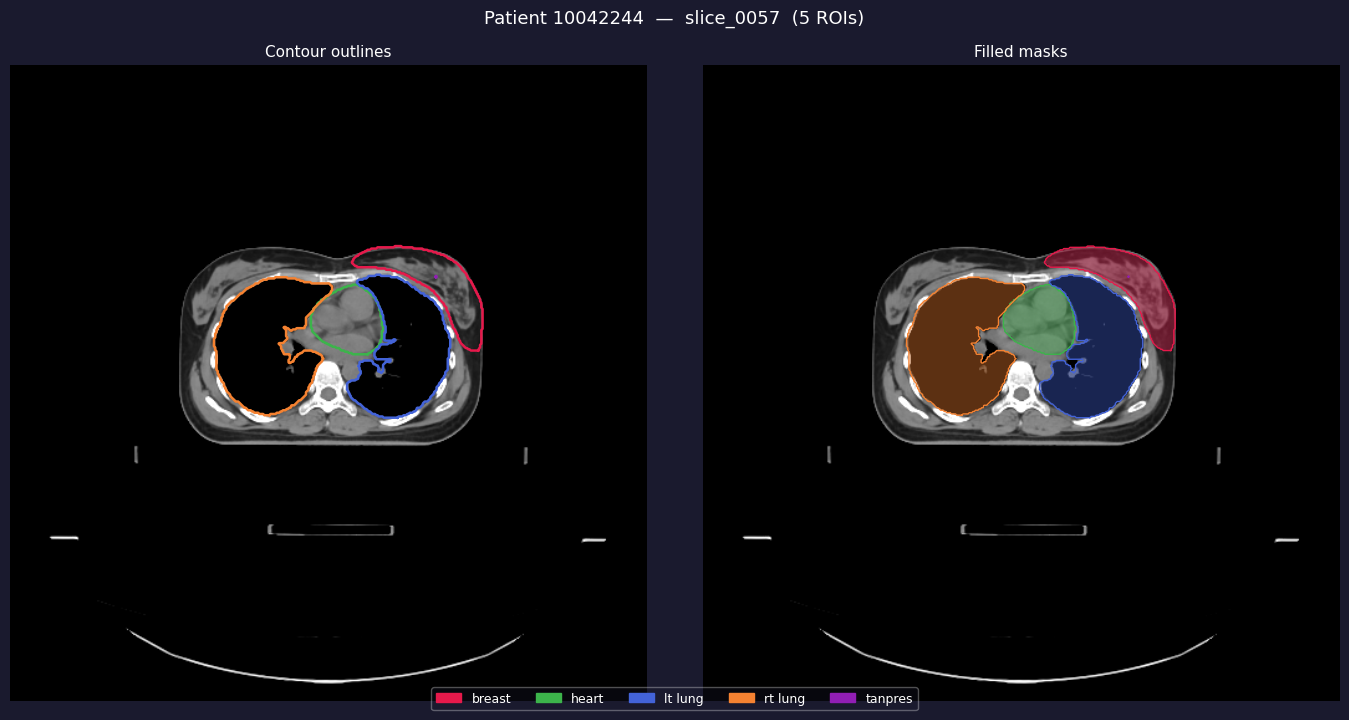

  Saved -> 10042341_viz.png


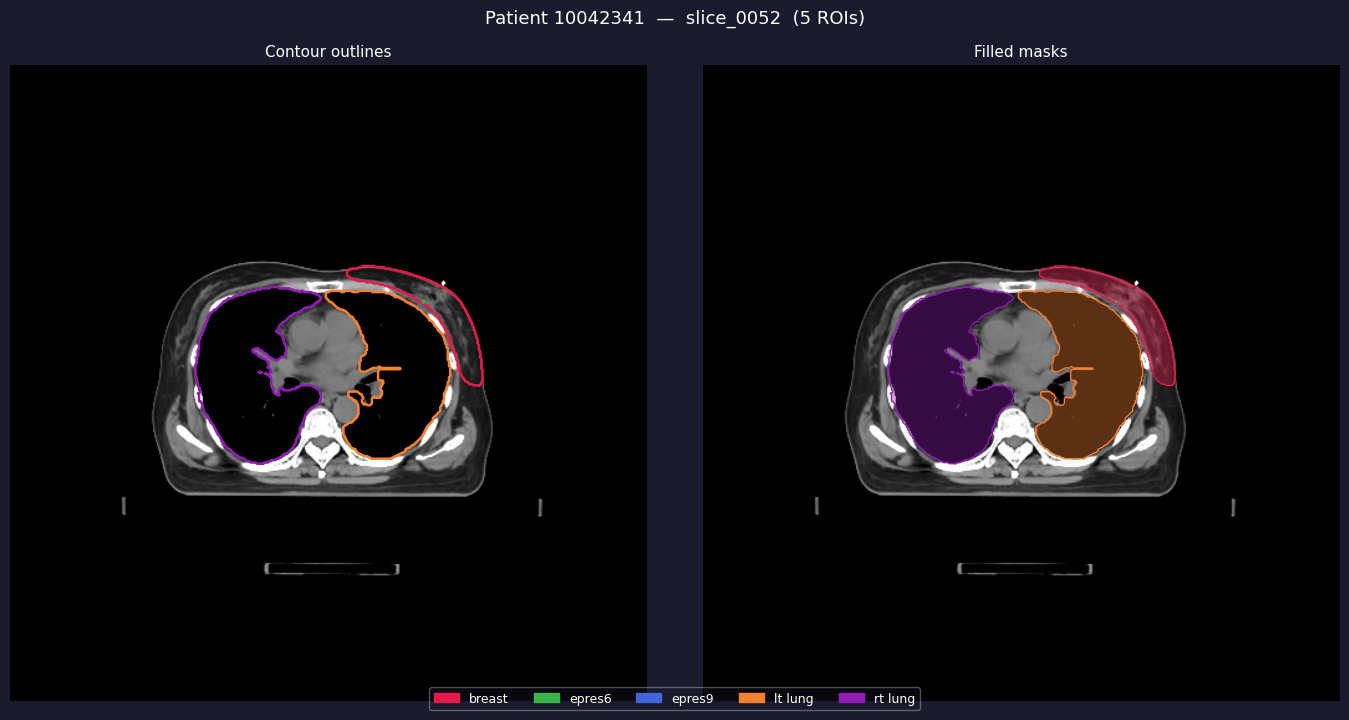

  Saved -> 10042532_viz.png


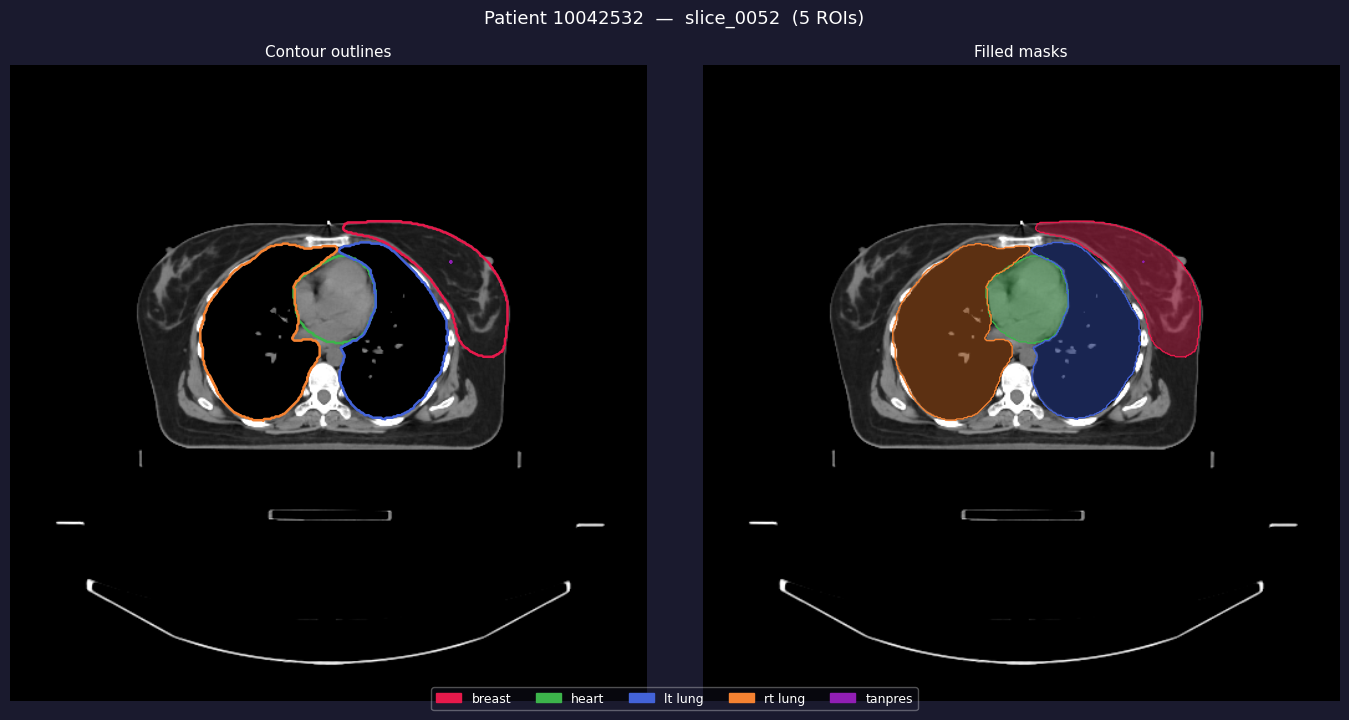

  Saved -> 10042956_viz.png


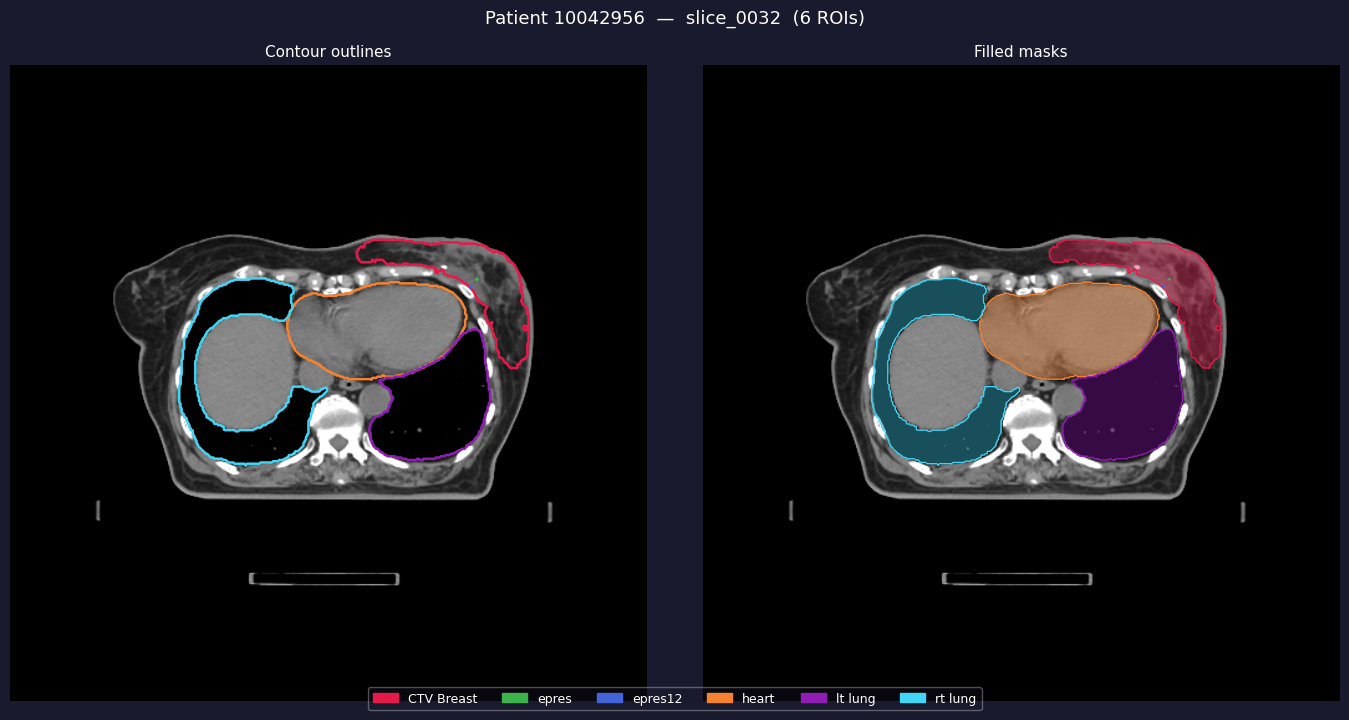

  Saved -> 10043058_viz.png


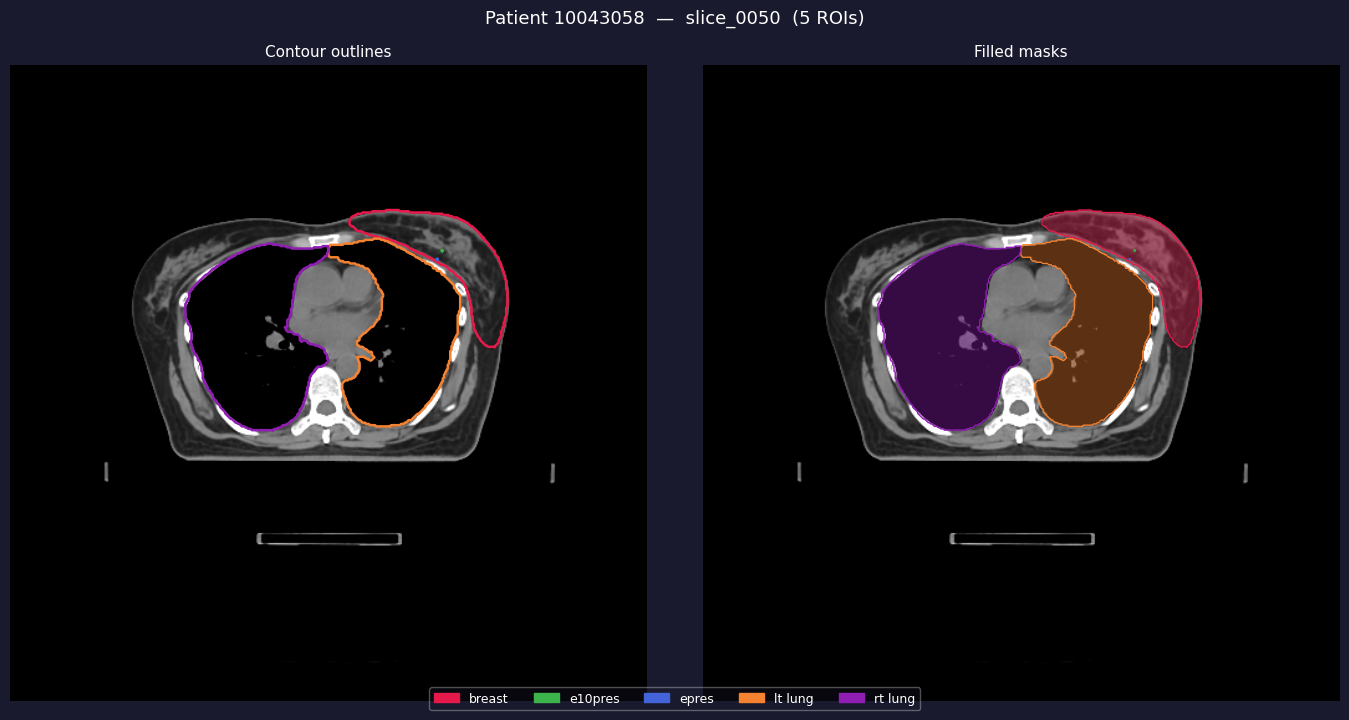

  Saved -> 10043734_viz.png


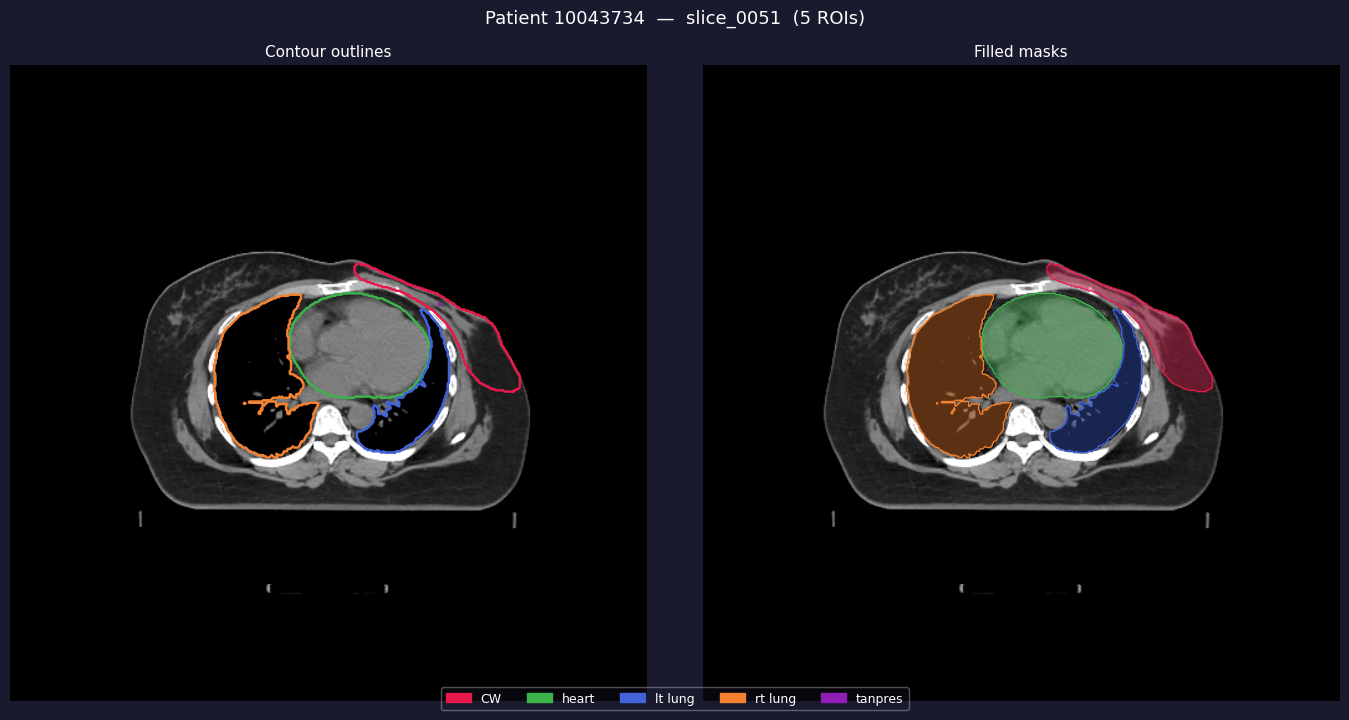

  Saved -> 10044186_viz.png


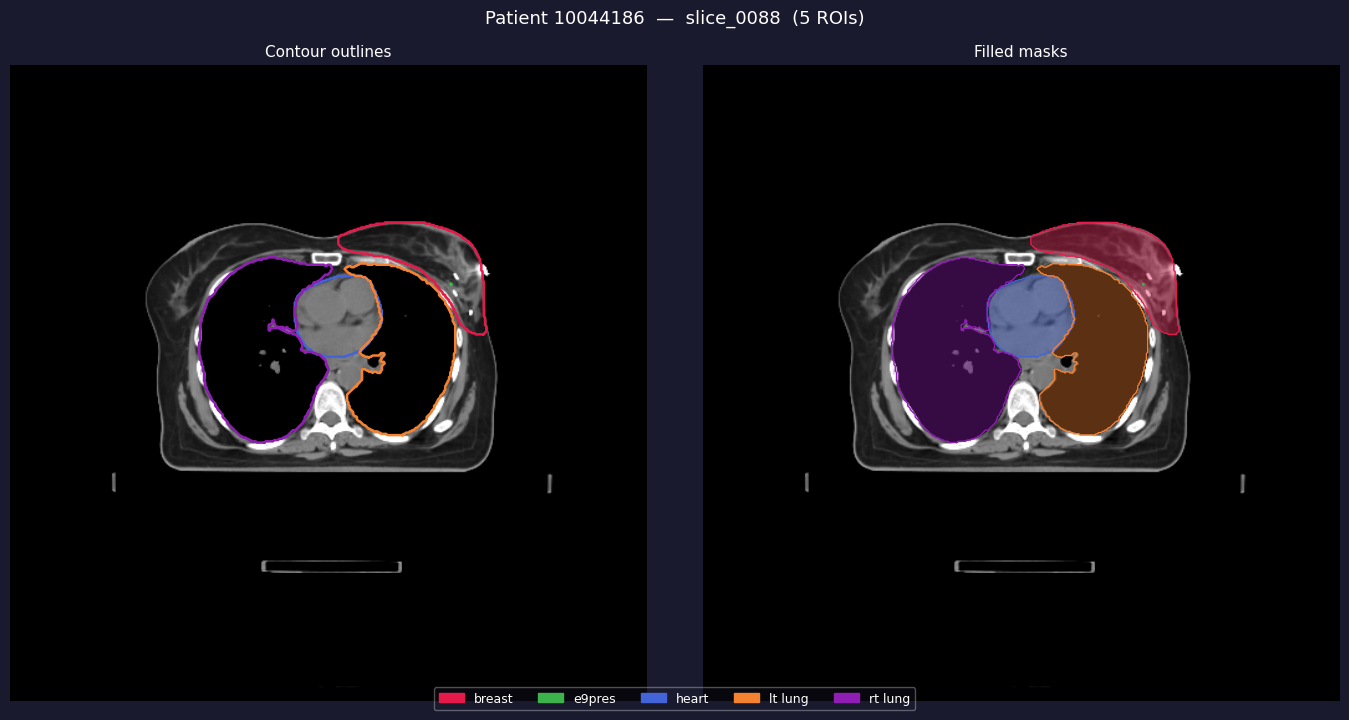

  Saved -> 10044541_viz.png


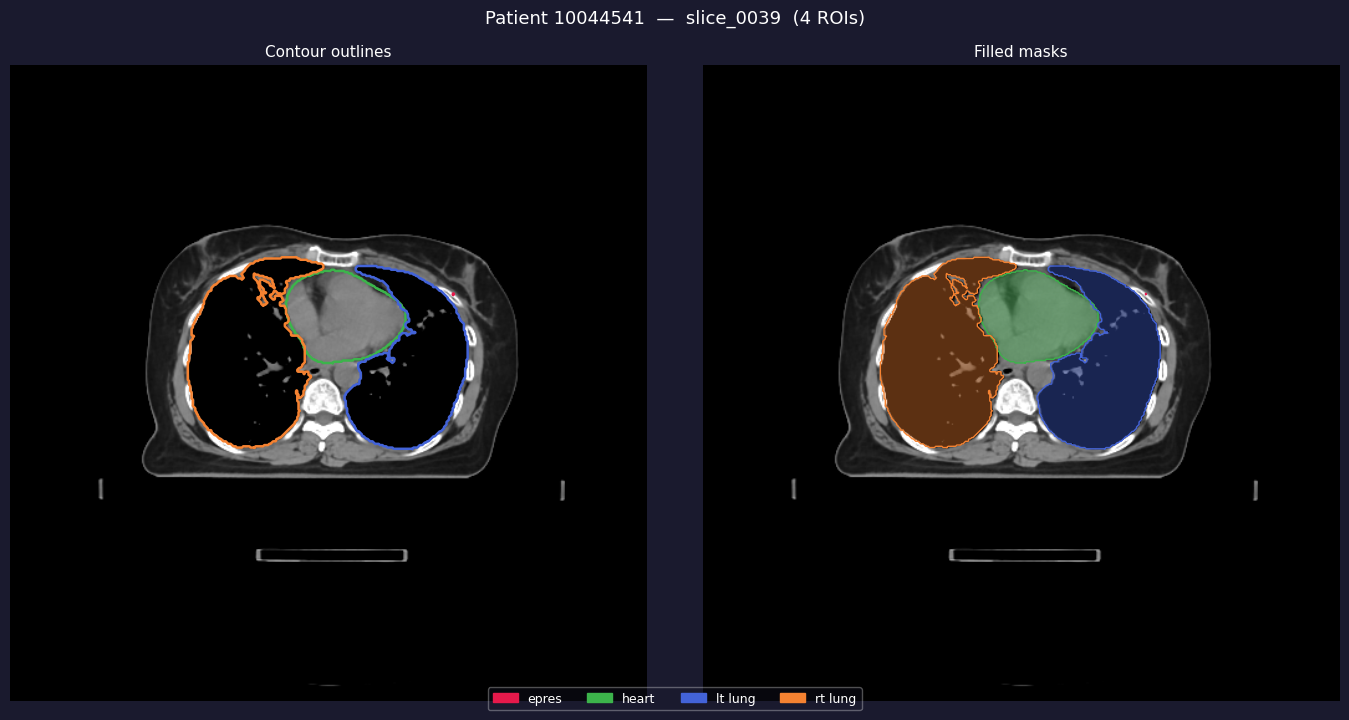

  Saved -> 10046256_viz.png


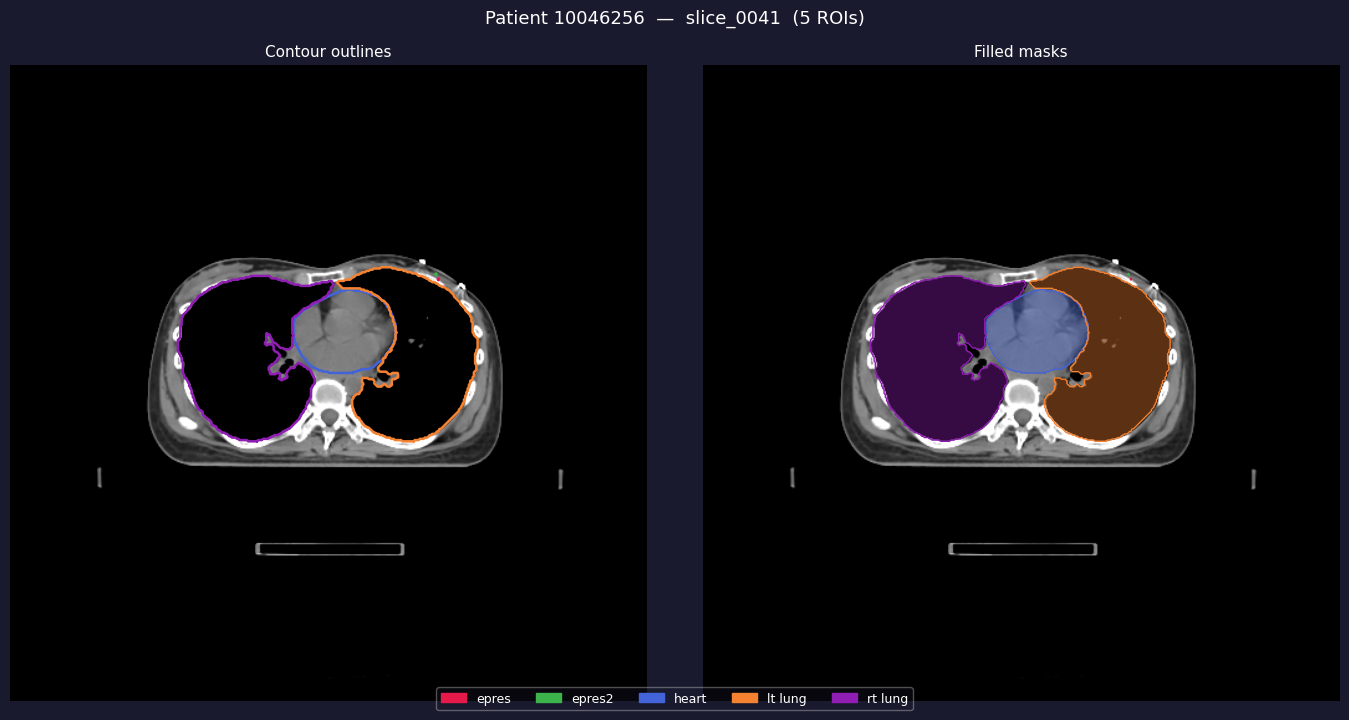

  Saved -> 10048093_viz.png


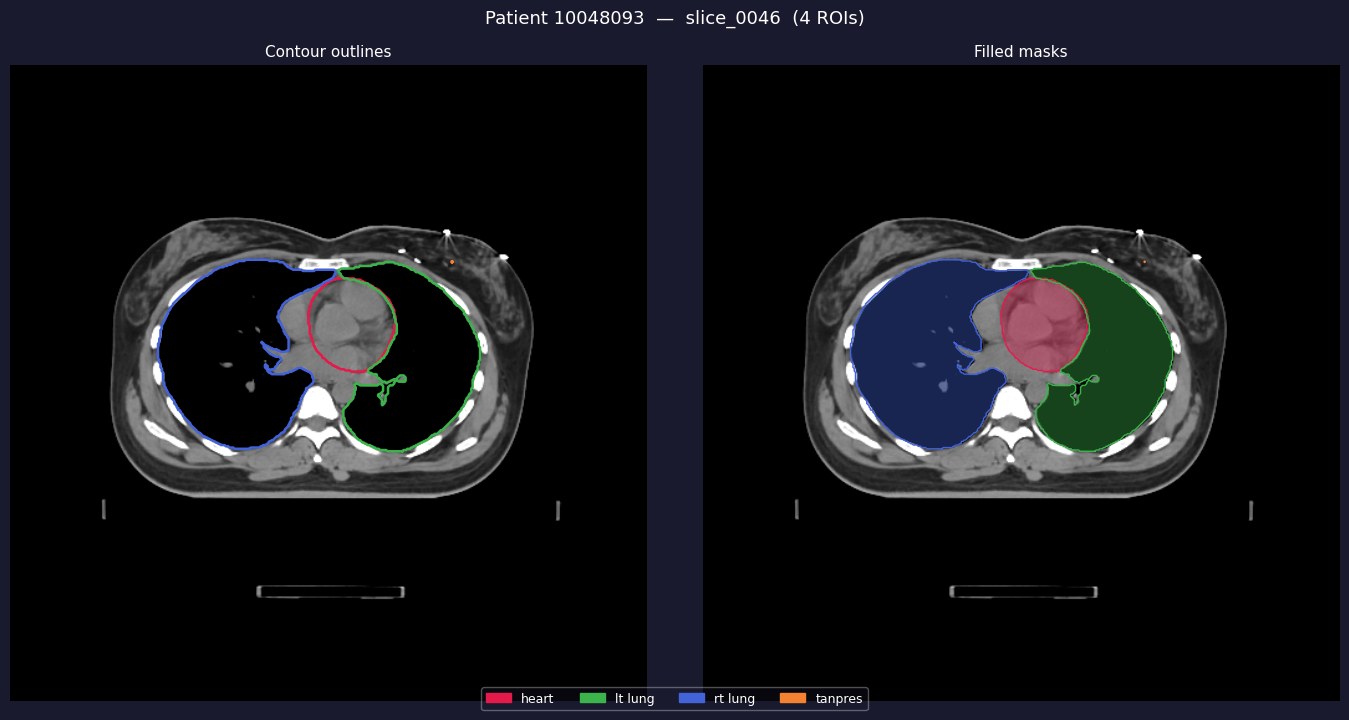

  Saved -> 10048099_viz.png


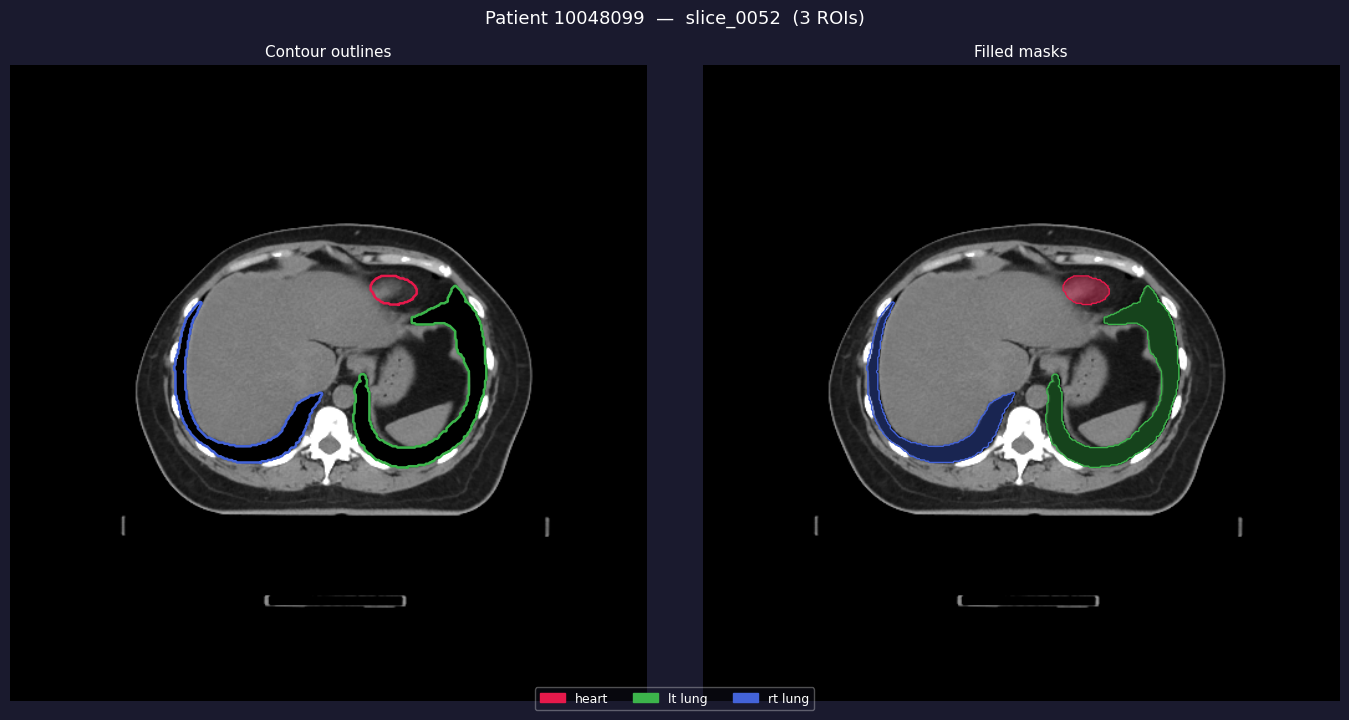

  Saved -> 10049453_viz.png


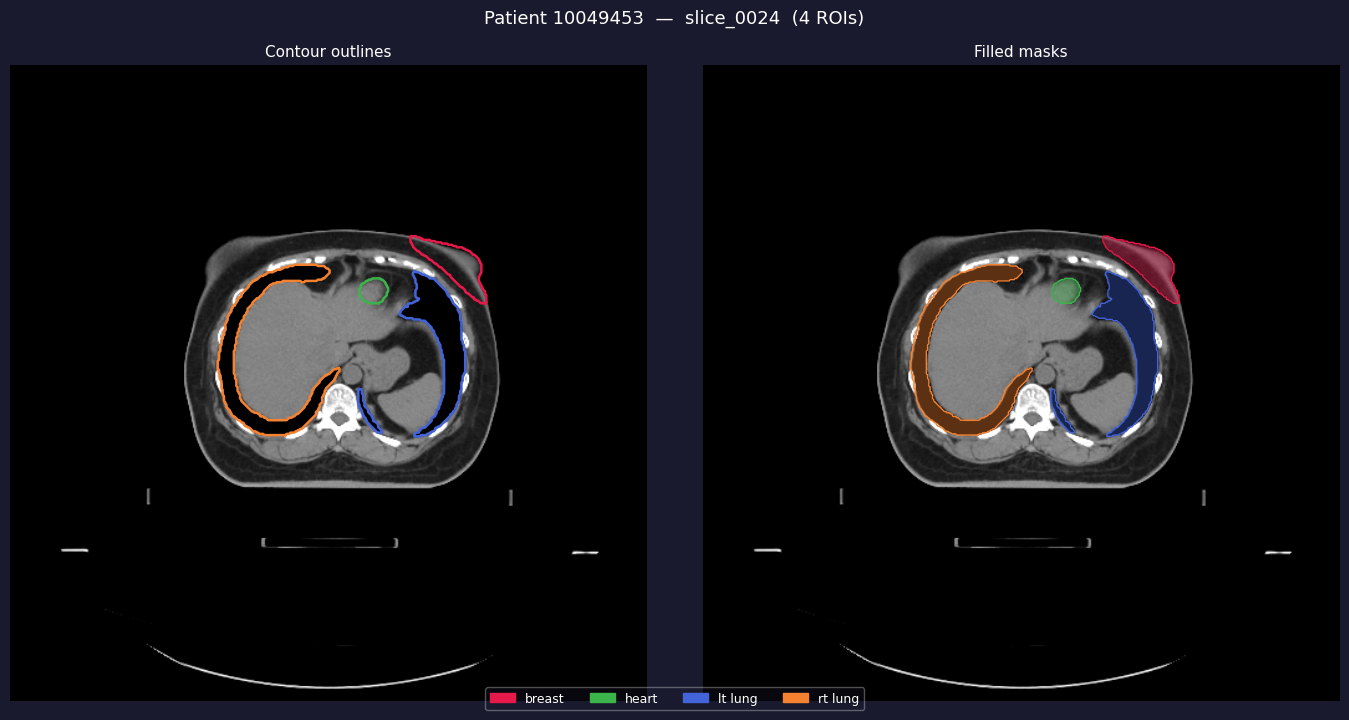

  Saved -> 10049577_viz.png


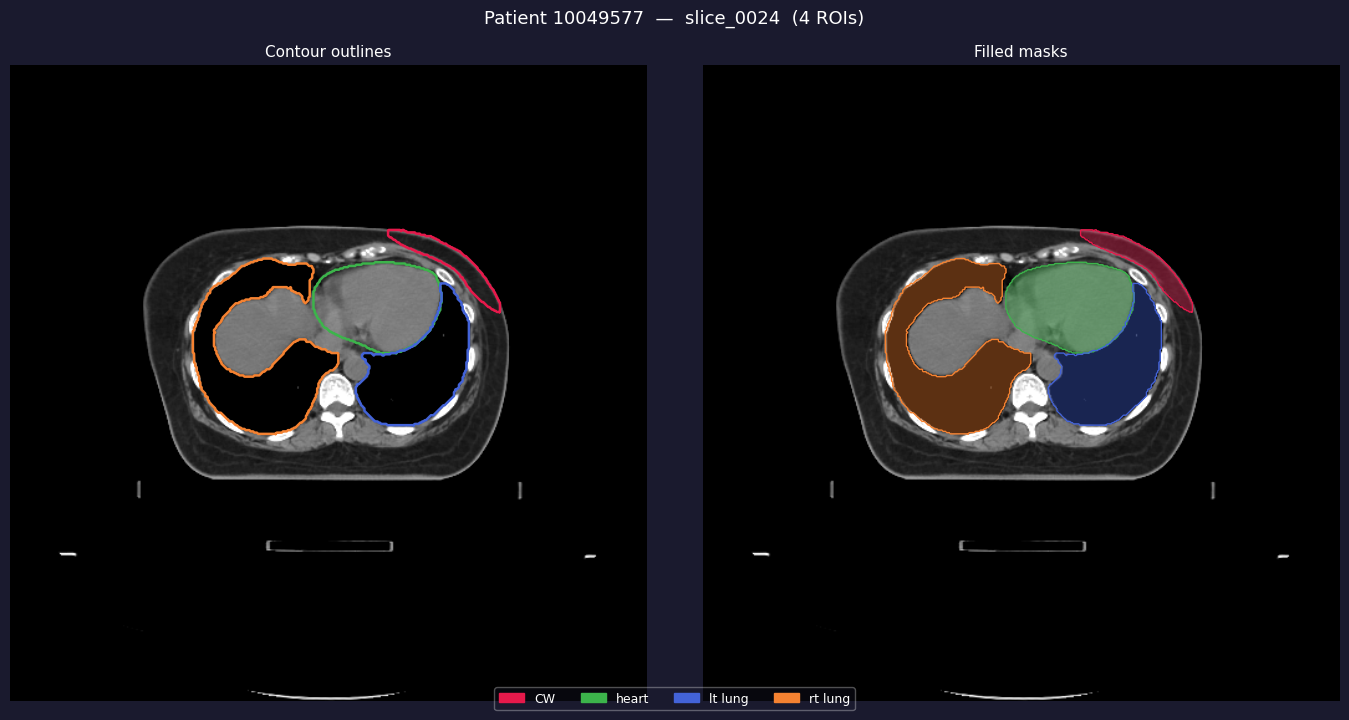

  Saved -> 10049961_viz.png


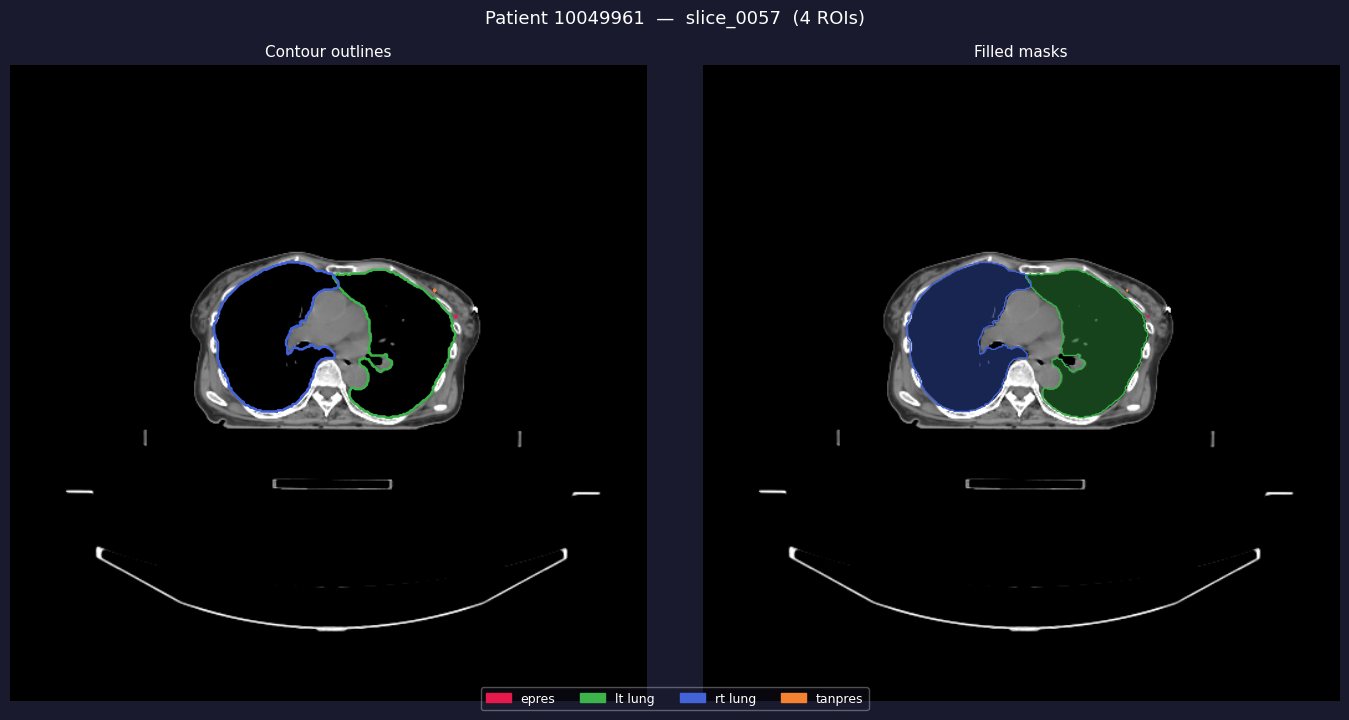

  Saved -> 10050196_viz.png


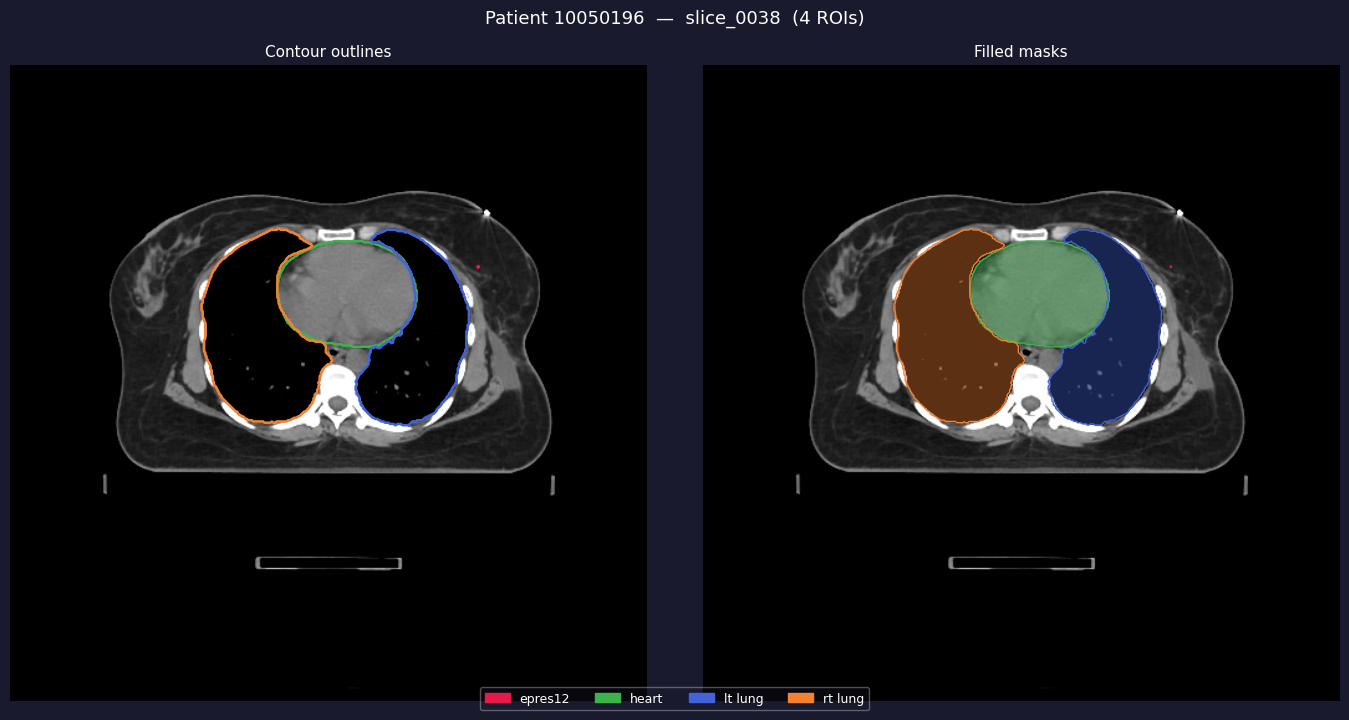

  Saved -> 10050824_viz.png


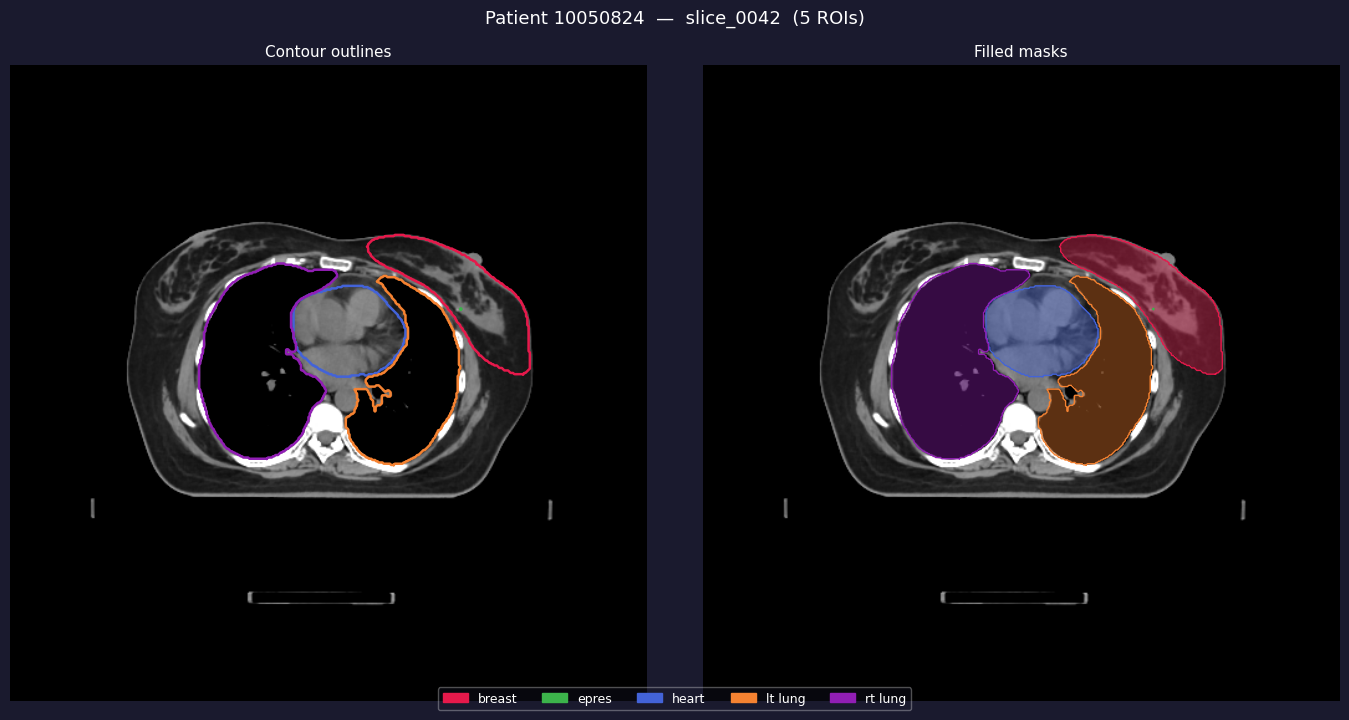

  Saved -> 10051652_viz.png


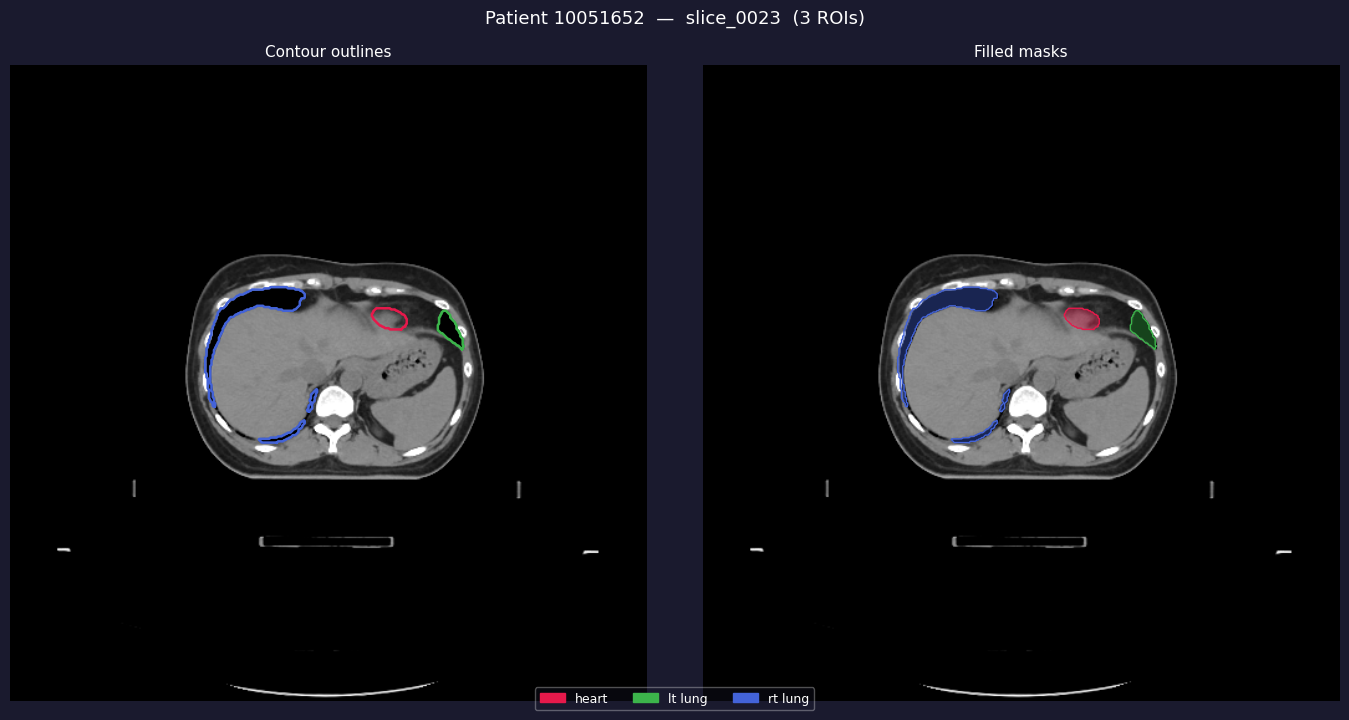

  Saved -> 10052278_viz.png


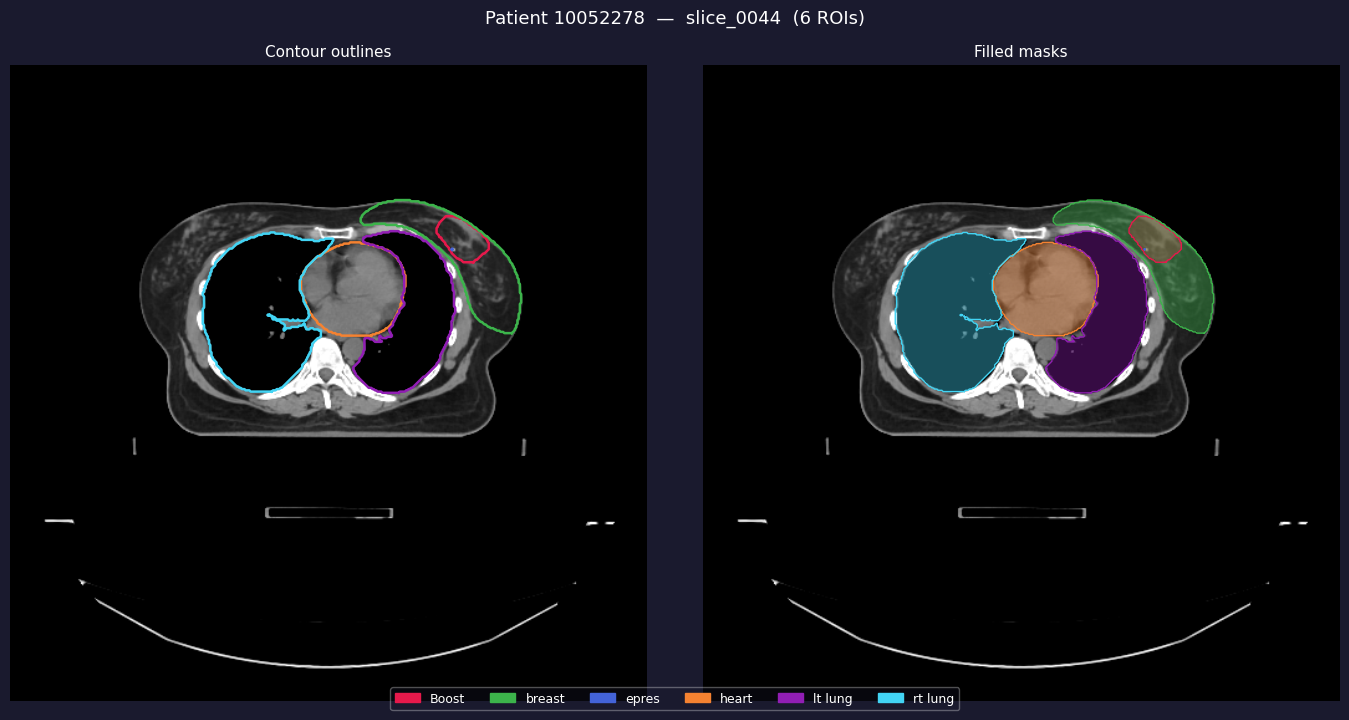

  Saved -> 10052972_viz.png


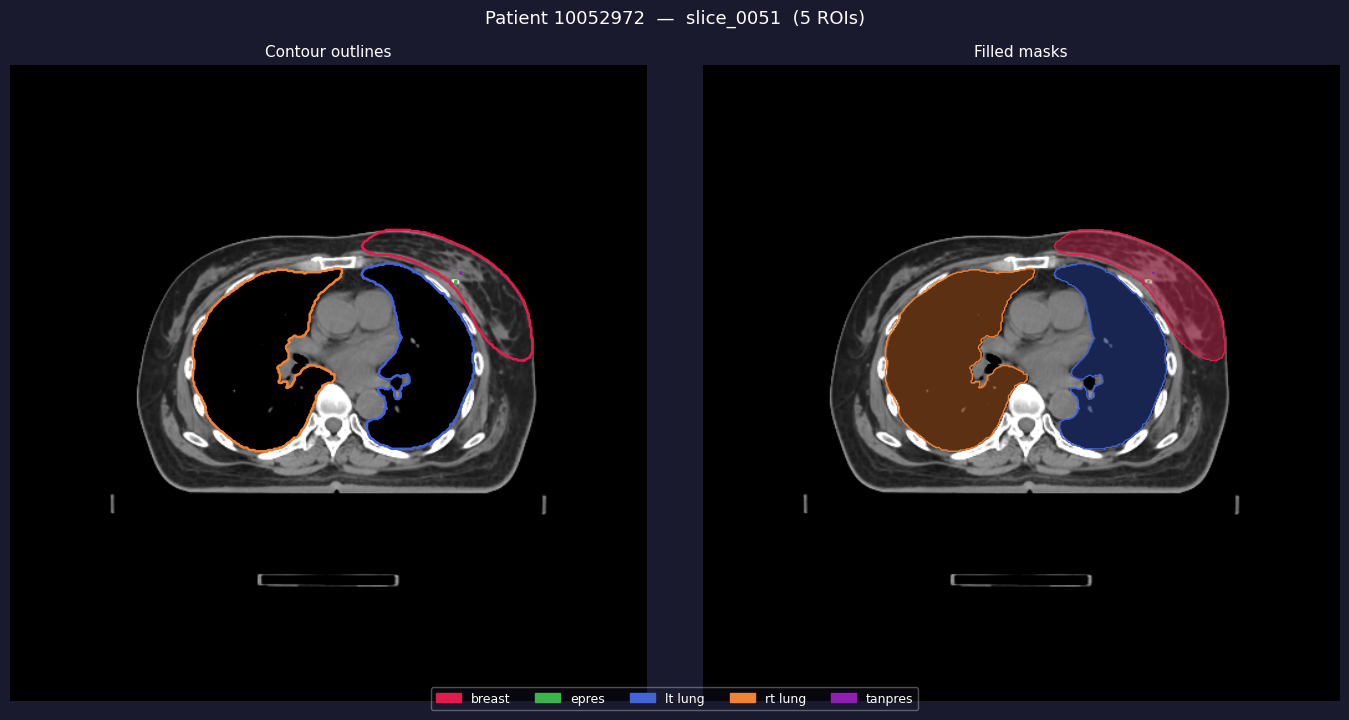

  Saved -> 10053188_viz.png


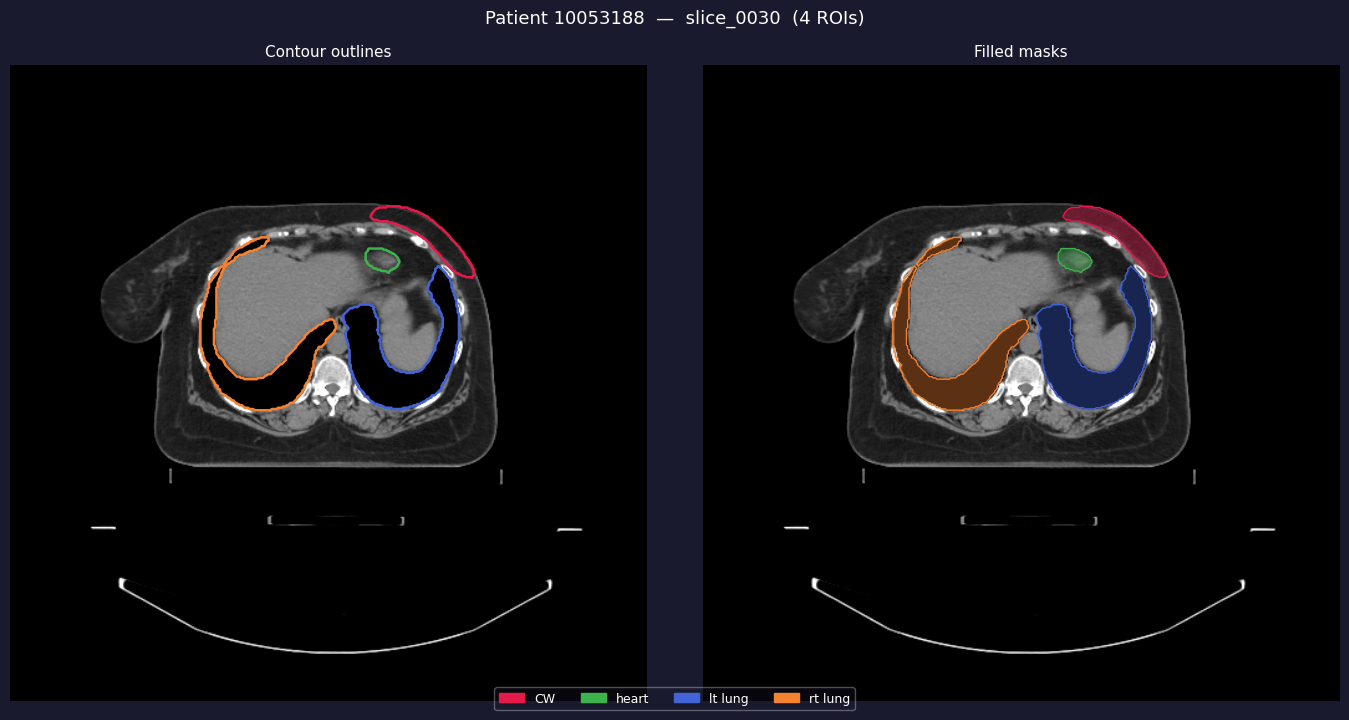

  Saved -> 10053550_viz.png


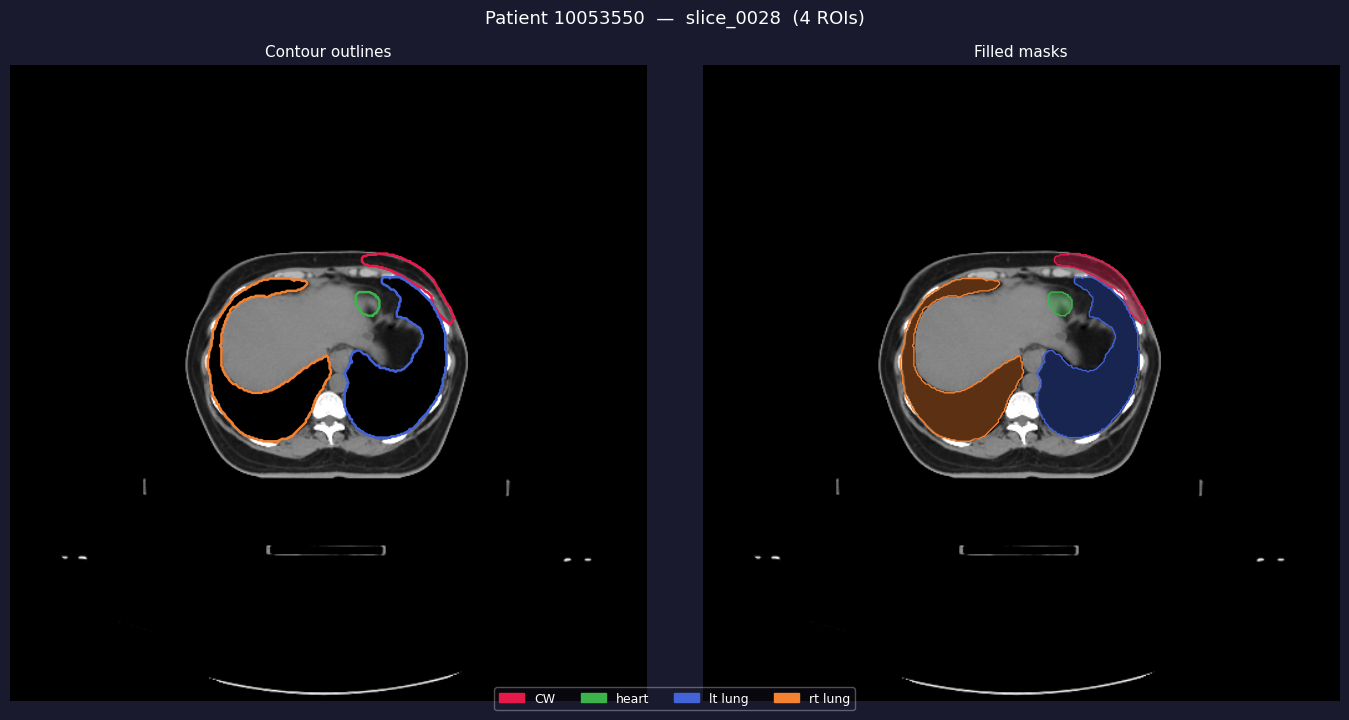

  Saved -> 10054748_viz.png


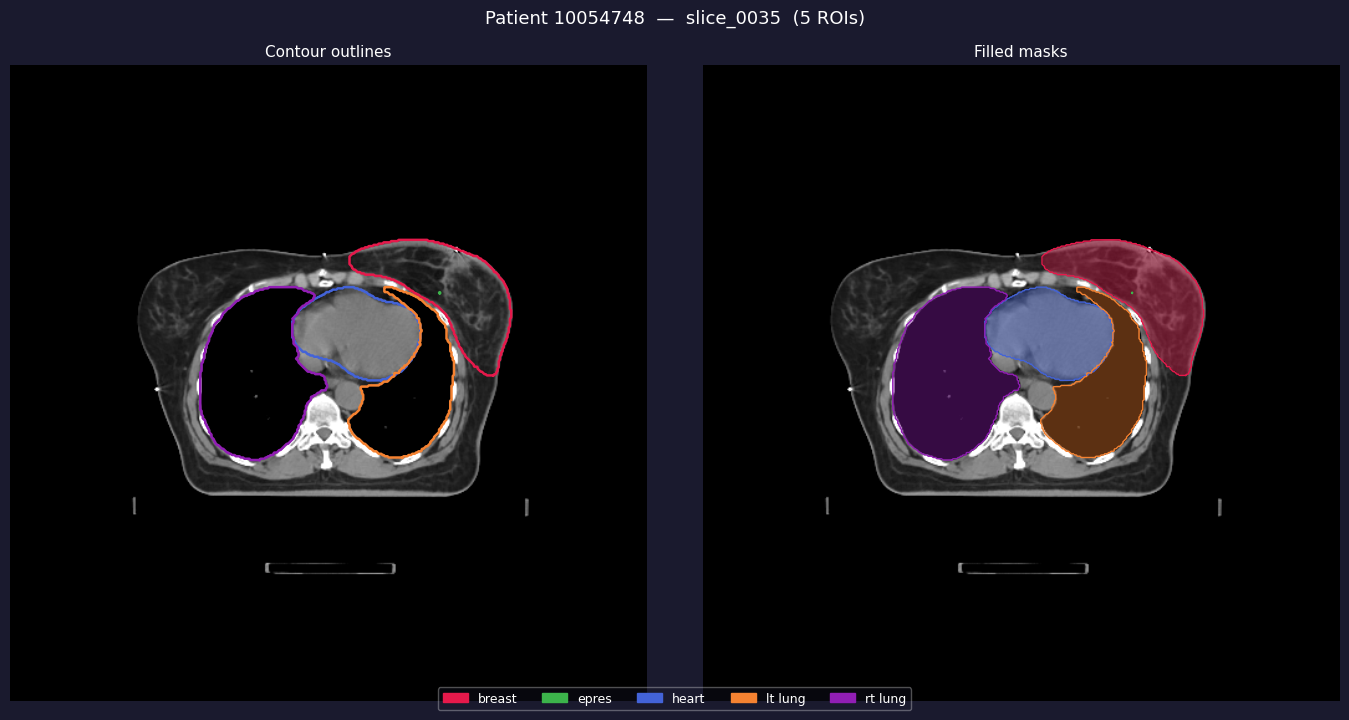

  Saved -> 10056121_viz.png


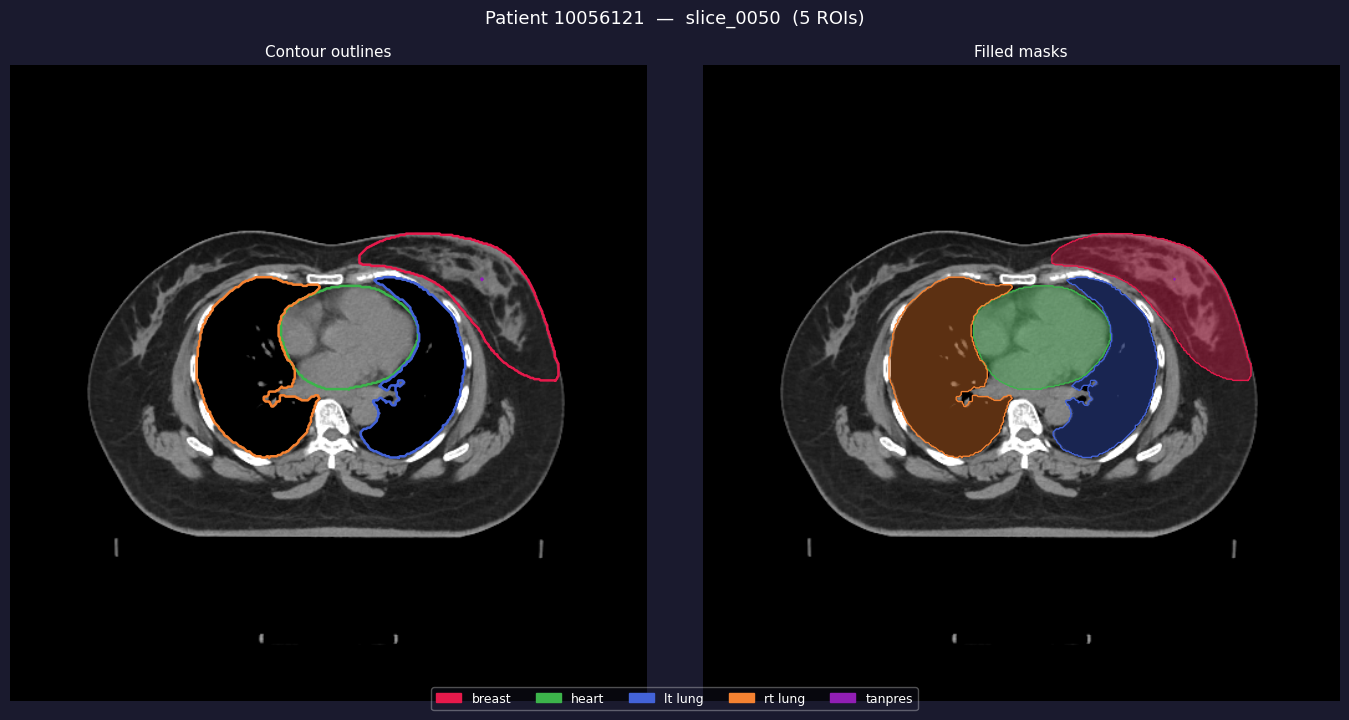

  Saved -> 10057016_viz.png


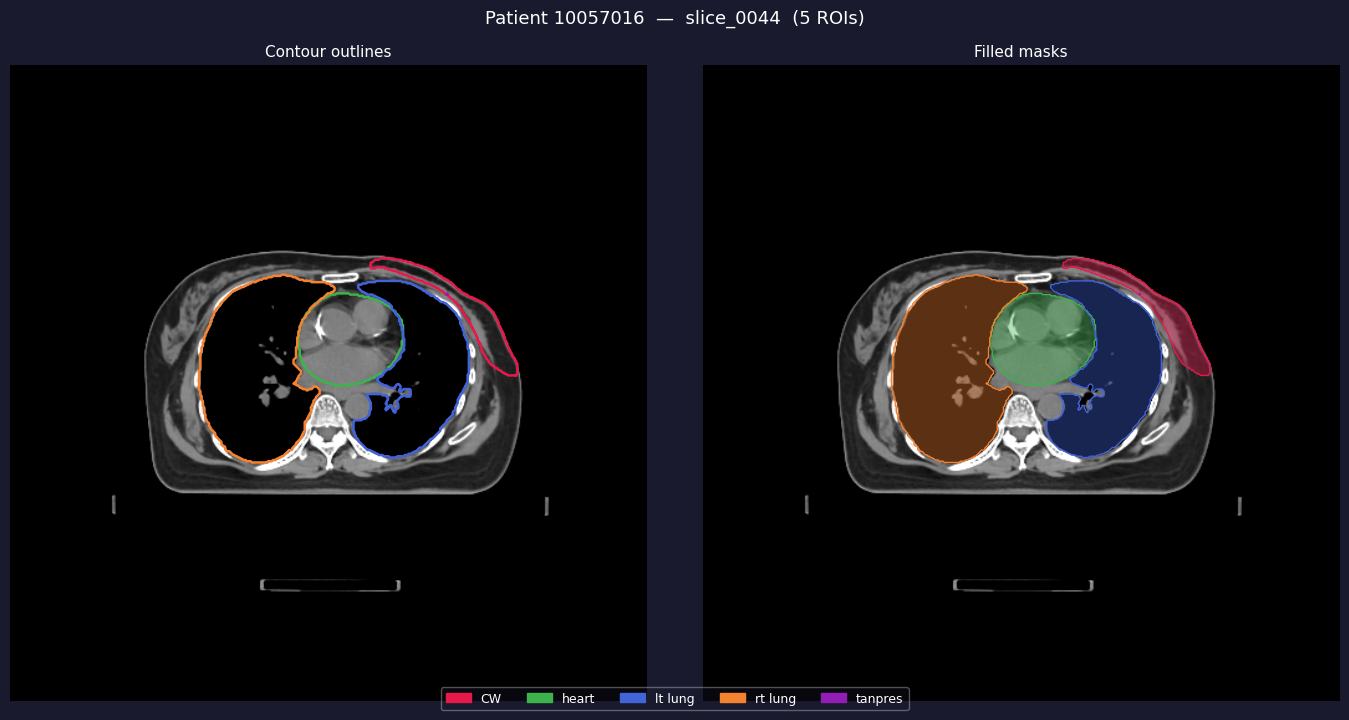

  Saved -> 10057395_viz.png


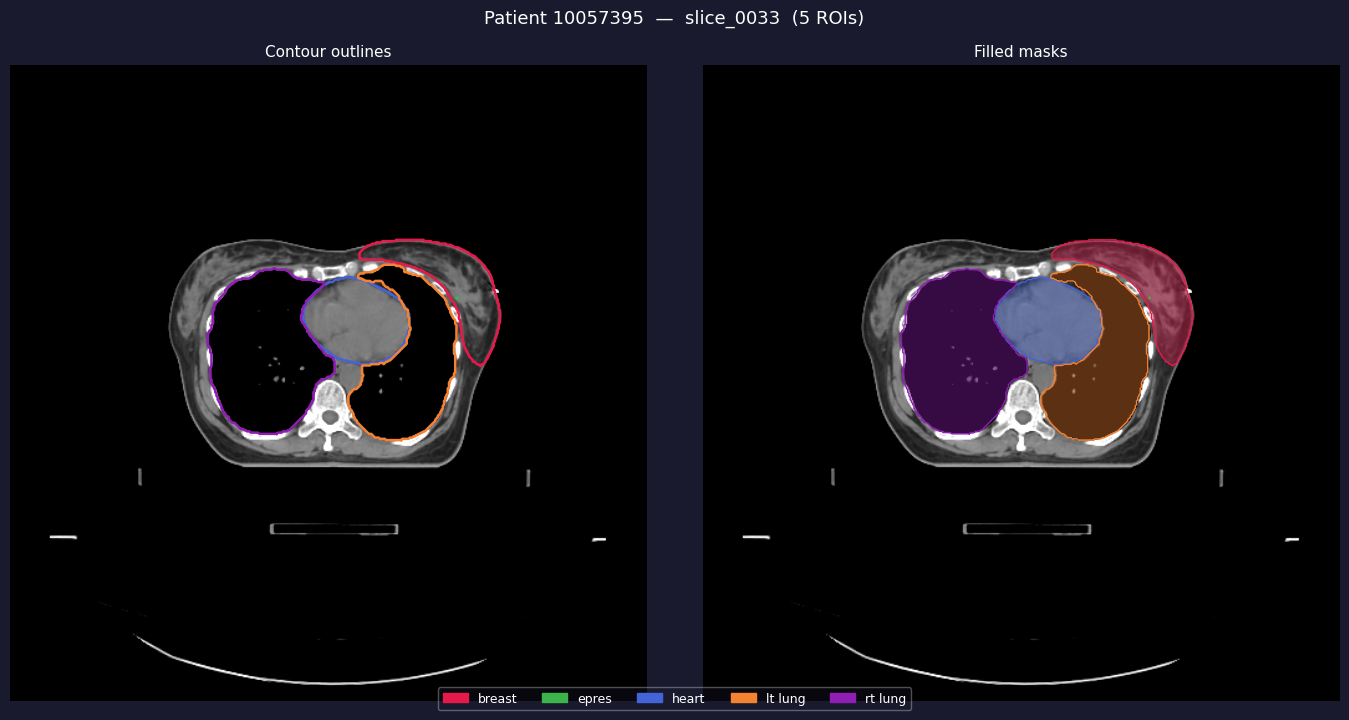

  Saved -> 10057560_viz.png


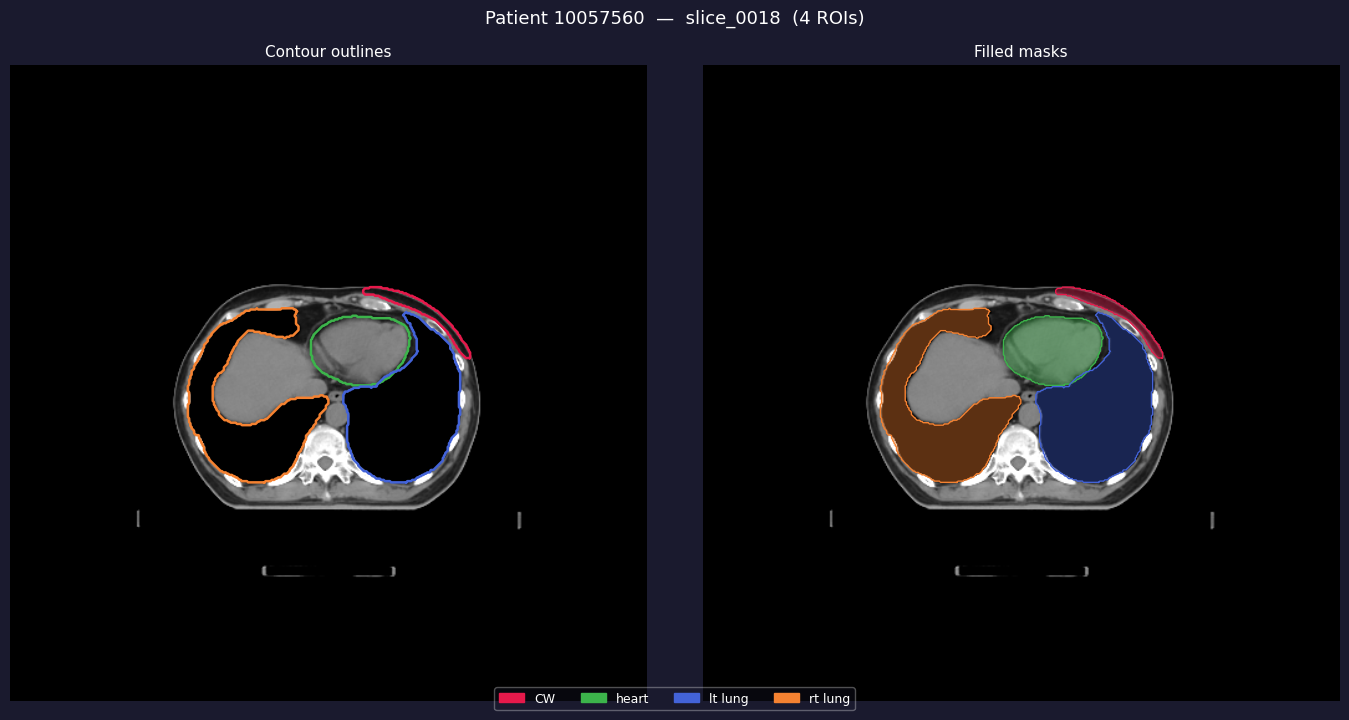

  Saved -> 10057737_viz.png


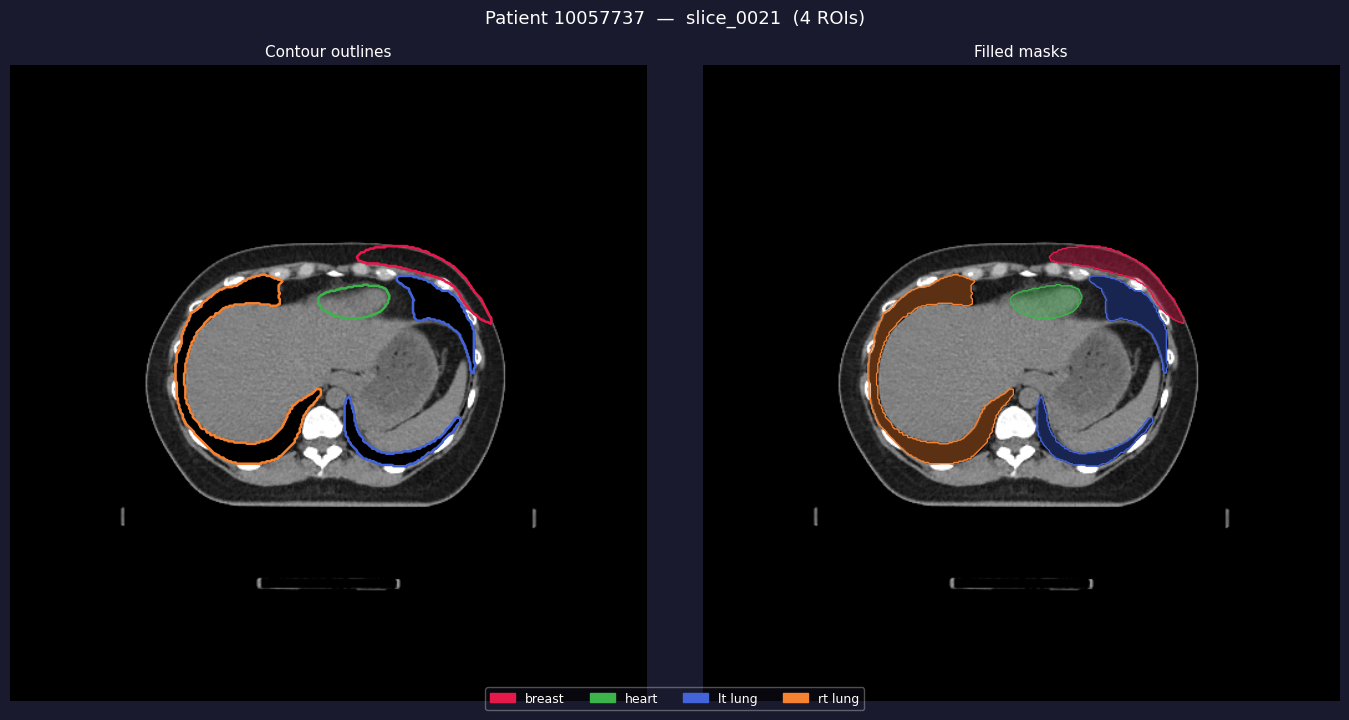

  Saved -> 10057874_viz.png


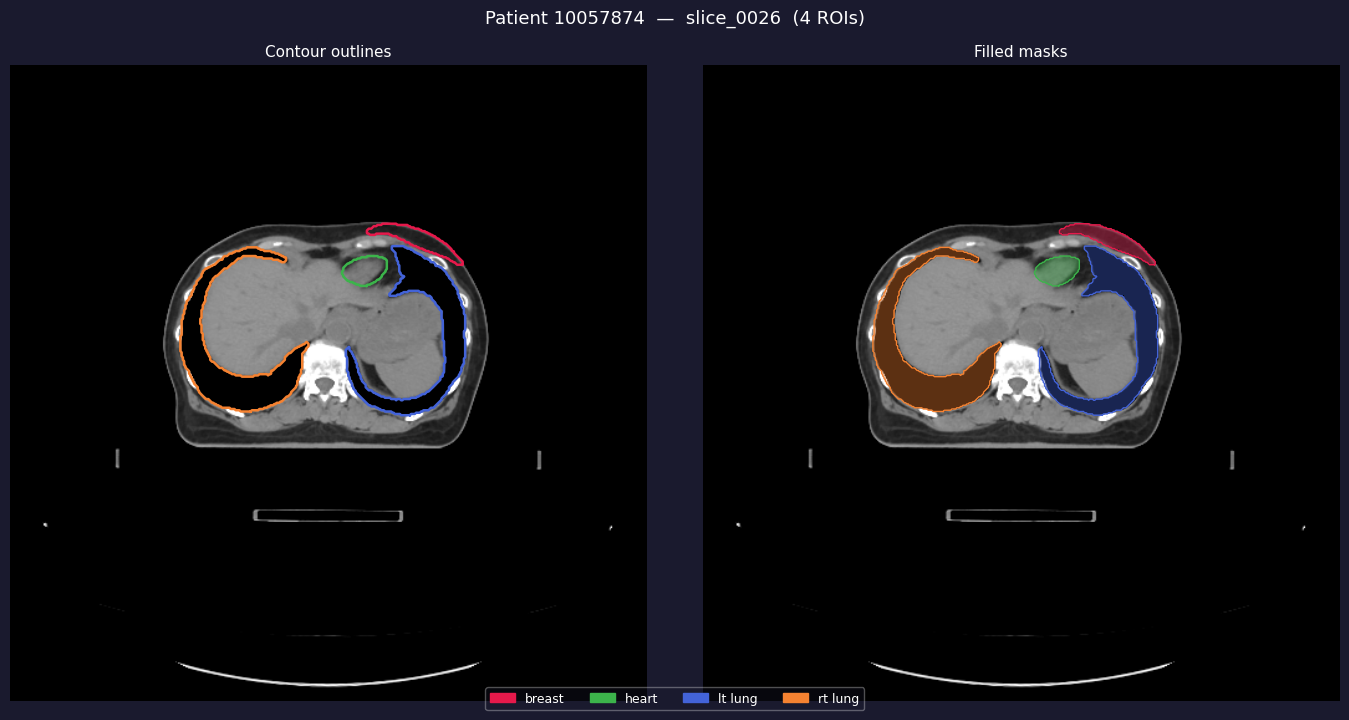

  Saved -> 10058192_viz.png


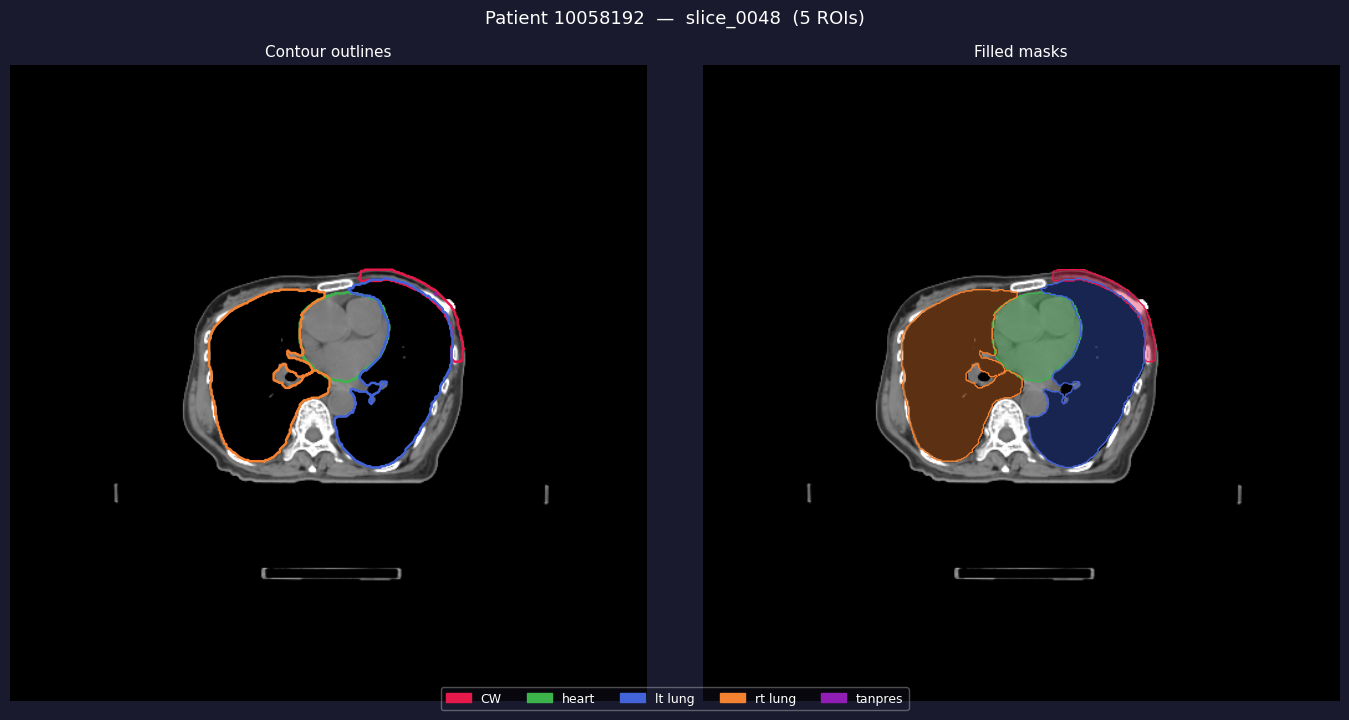

  No .h5 for 10059544
  Saved -> 10059916_viz.png


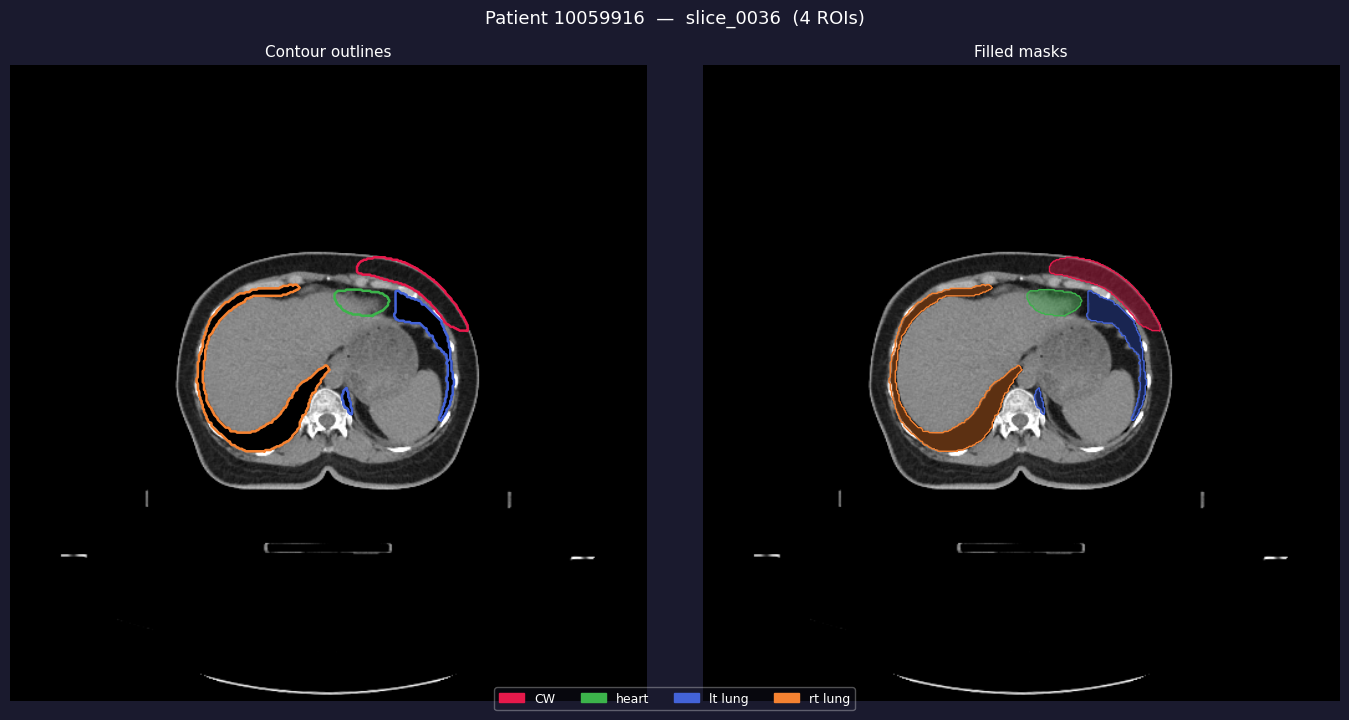

  Saved -> 10061011_viz.png


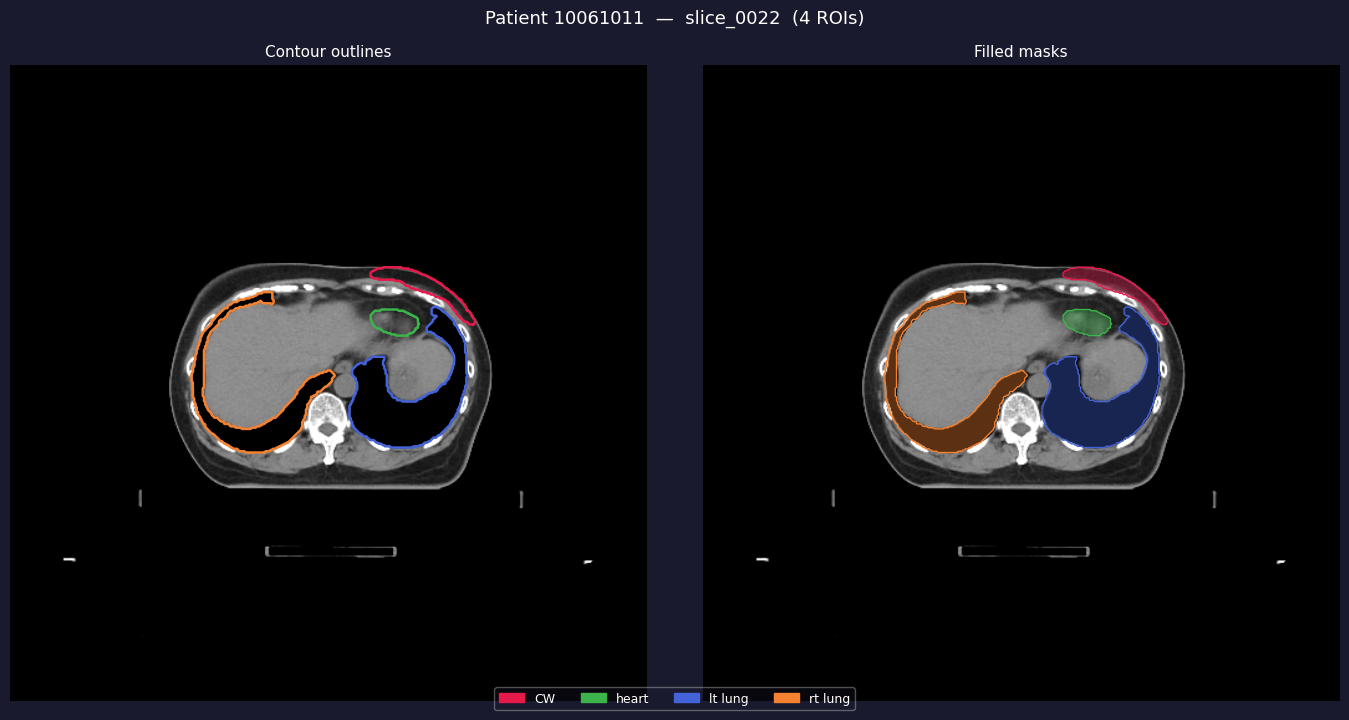

  Saved -> 10061391_viz.png


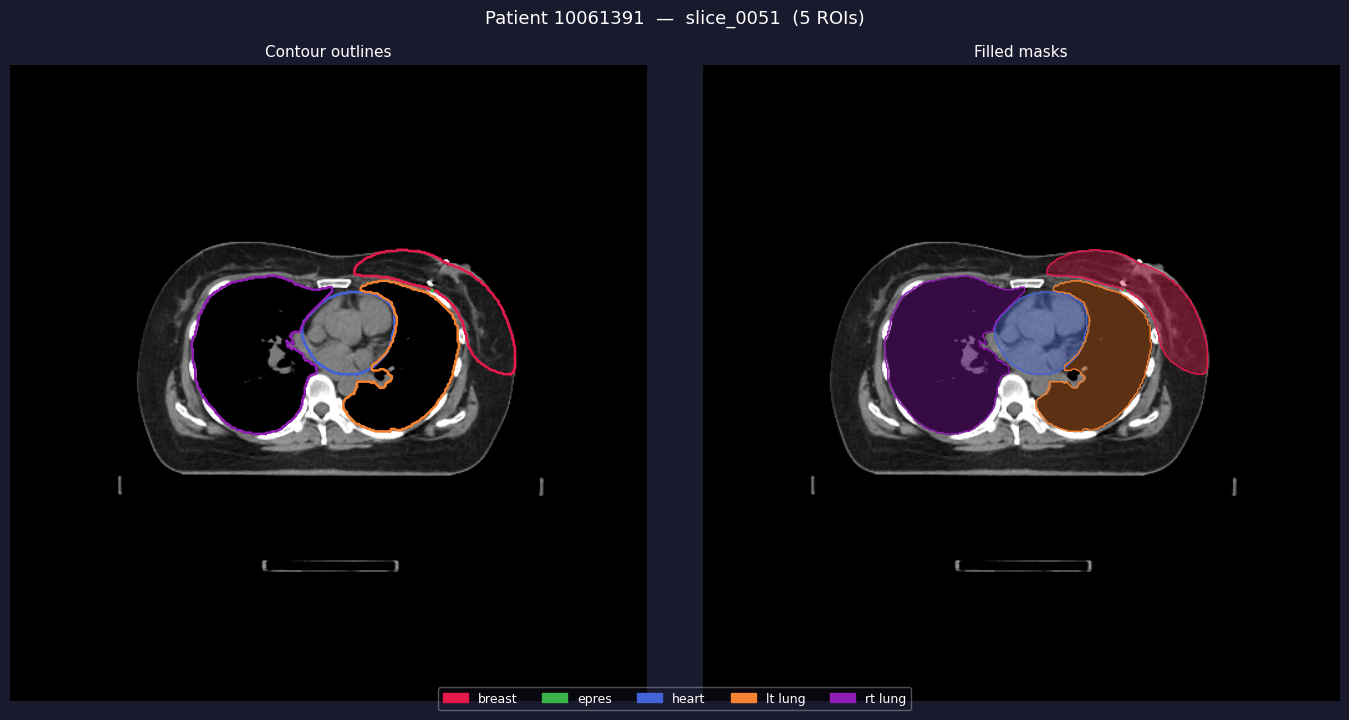

  Saved -> 10061823_viz.png


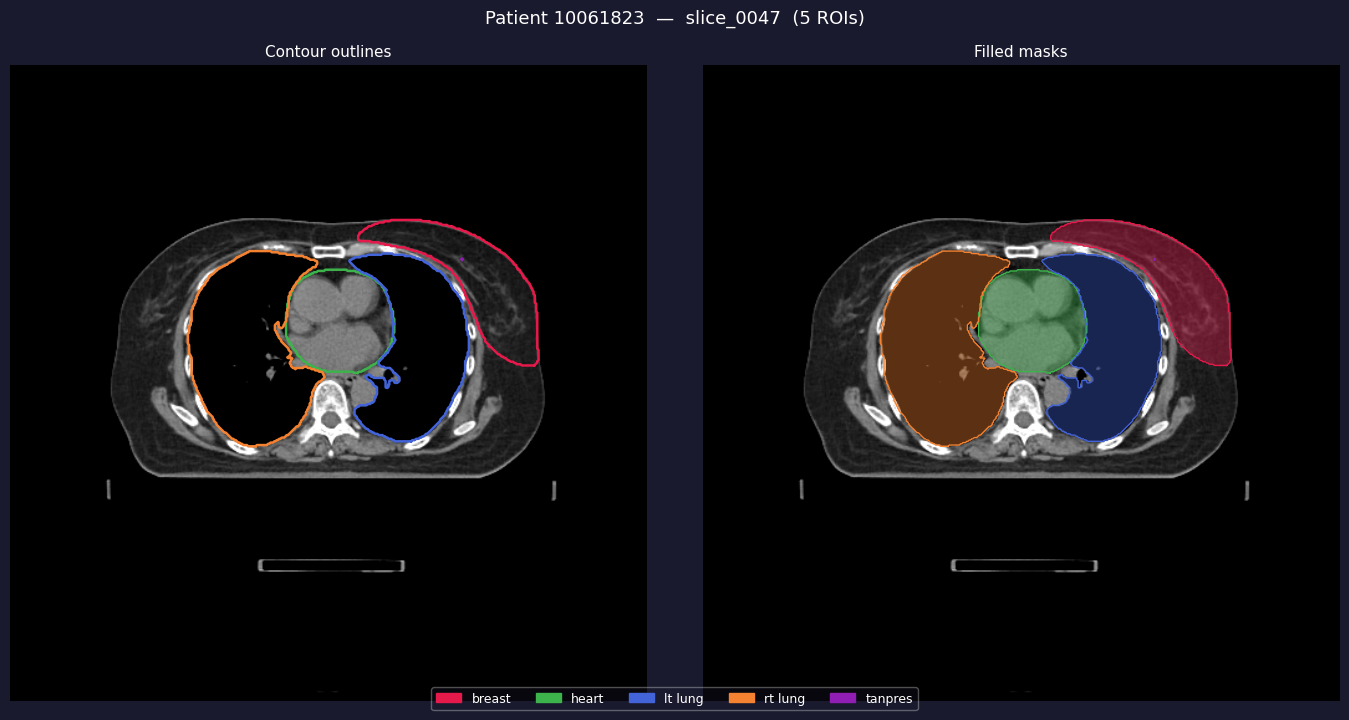

  Saved -> 10062202_viz.png


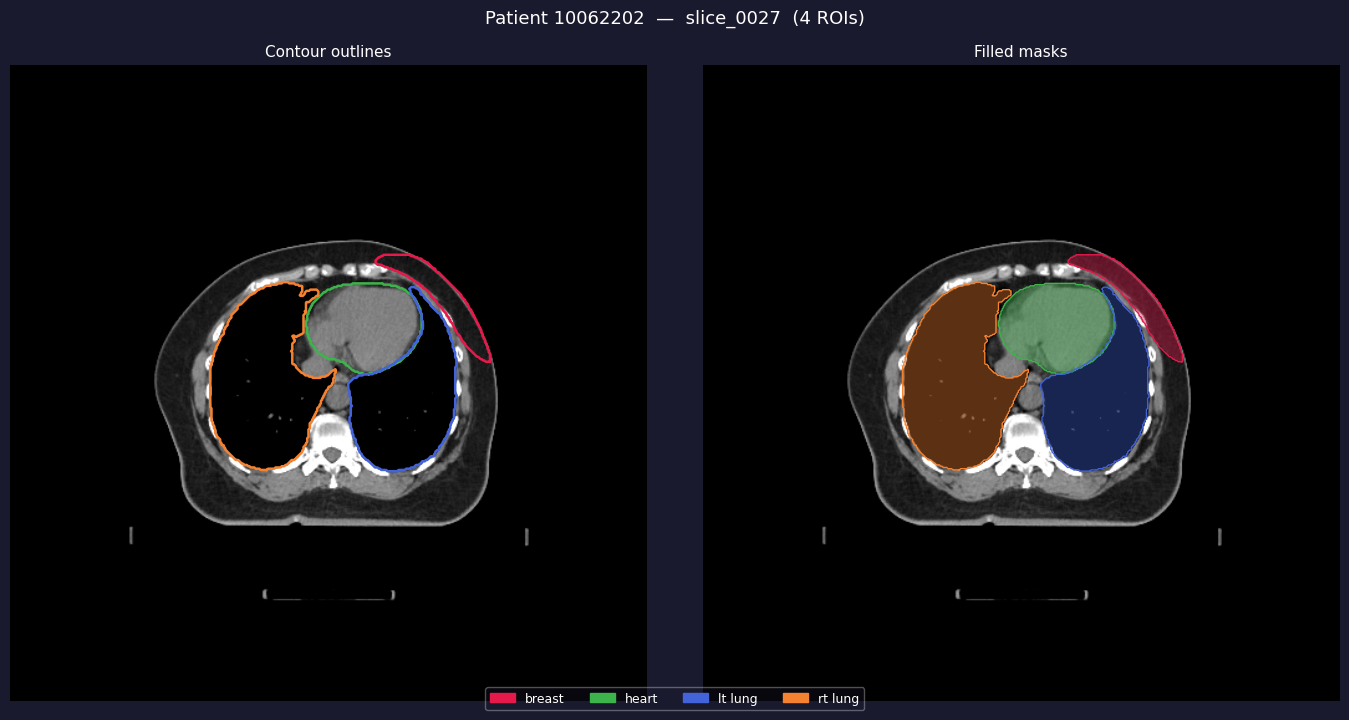

  Saved -> 10062723_viz.png


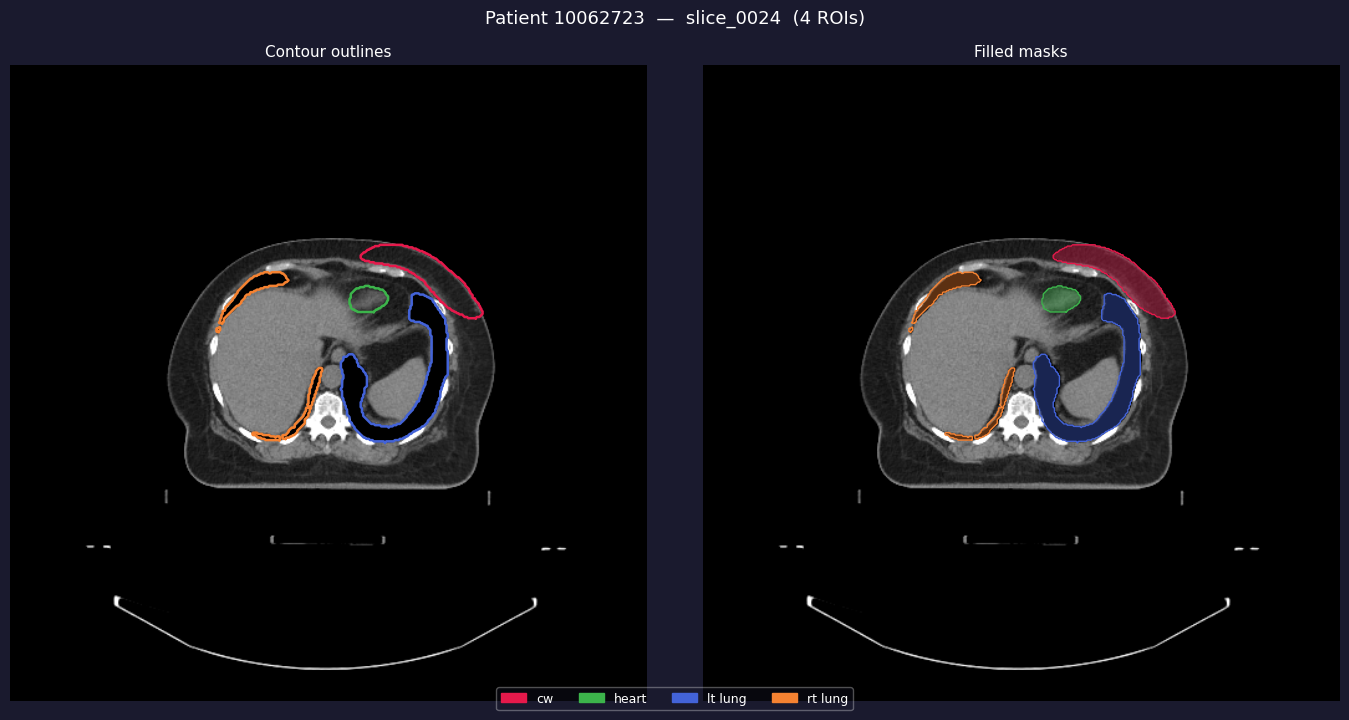

  Saved -> 10063911_viz.png


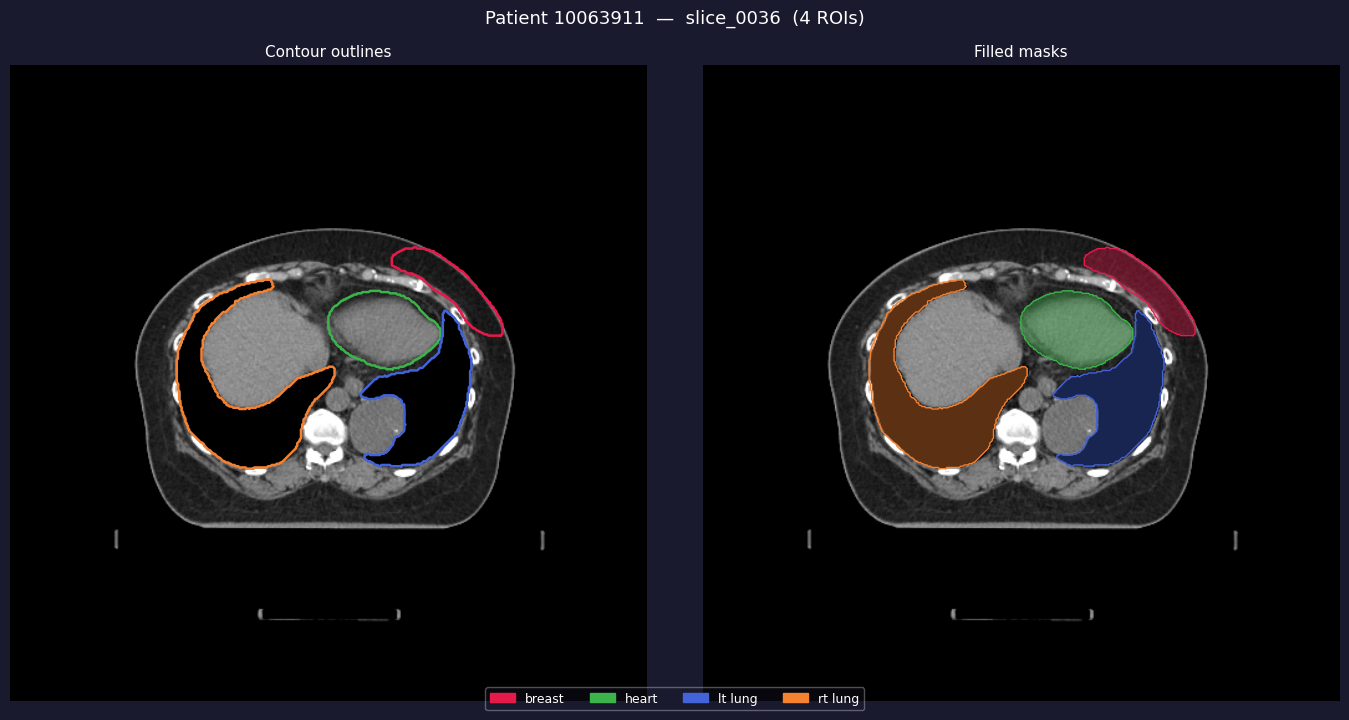

  Saved -> 10064227_viz.png


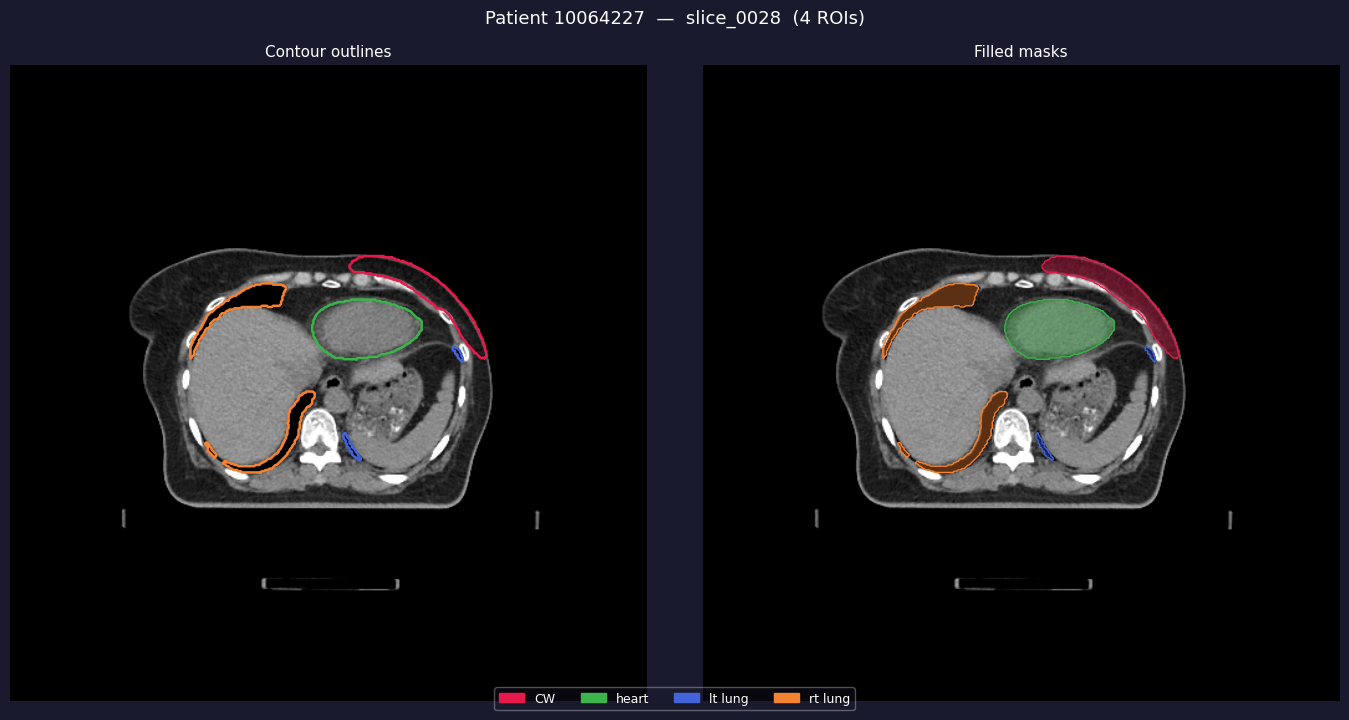

  Saved -> 10064436_viz.png


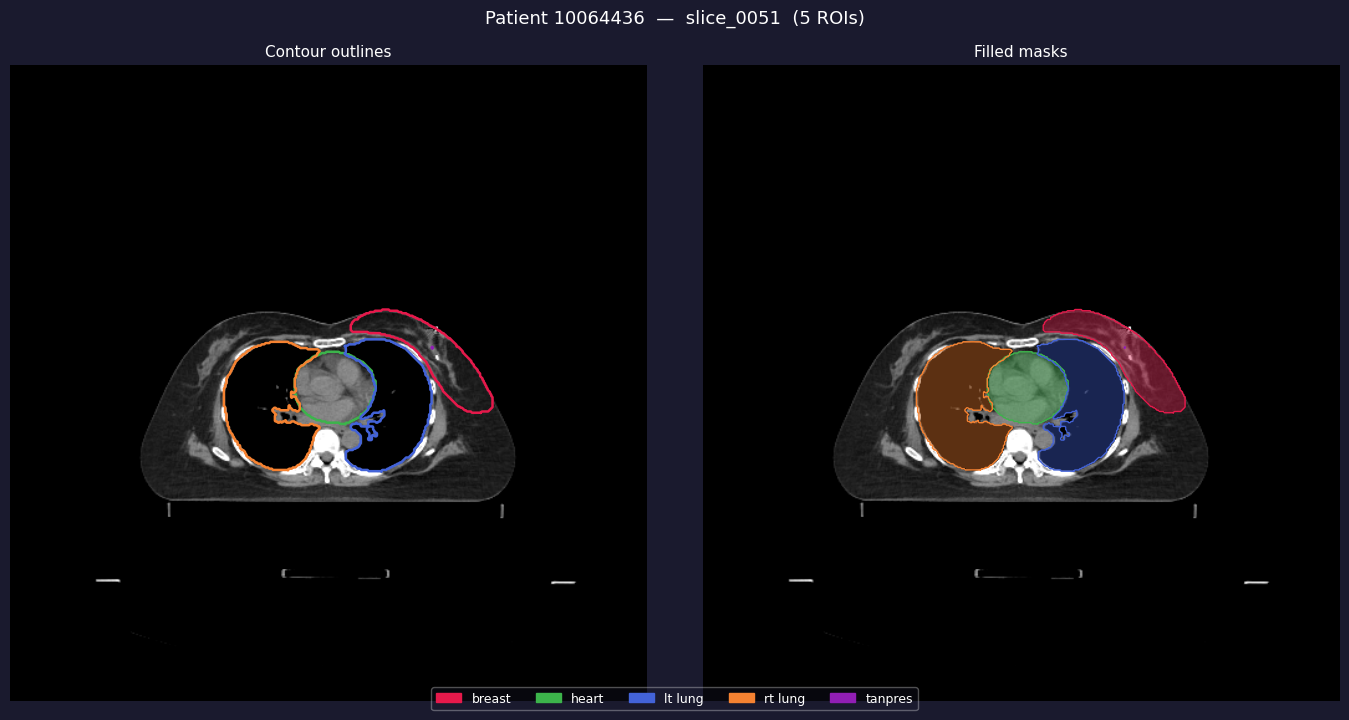

In [10]:
# Visualise ALL patients
for patient_dir in tqdm(patient_dirs, desc='Visualising'):
    visualise_patient_h5(patient_dir.name, OUTPUT_DIR, save_png=True)

## 7 · How to Load a Patient for ML Training

In [11]:
# Example: load all annotated slices for one patient as numpy arrays
def load_patient_h5(patient_id, output_dir, roi_filter=None):
    """
    Load all slices with masks from a patient HDF5 file.

    Args:
        patient_id  : e.g. '10006761'
        output_dir  : Path to dicom_pipeline_output/
        roi_filter  : list of ROI names to load, e.g. ['rt_lung', 'lt_lung']
                      None = load all ROIs

    Returns:
        images : np.ndarray  shape (N, 512, 512)  int16
        masks  : dict { roi_name : np.ndarray (N, 512, 512) bool }
        z_vals : np.ndarray  shape (N,)  float32  — Z position in mm
    """
    h5_path = output_dir / patient_id / f'{patient_id}_annotations.h5'
    images, z_vals = [], []
    masks_dict = {}

    with h5py.File(str(h5_path), 'r') as hf:
        for sk in sorted(hf.keys()):
            grp = hf[sk]
            if 'masks' not in grp:
                continue
            images.append(grp['pixels'][:])
            z_vals.append(float(grp['z'][0]))
            for roi_name in grp['masks'].keys():
                if roi_filter and roi_name not in roi_filter:
                    continue
                masks_dict.setdefault(roi_name, []).append(grp['masks'][roi_name][:])

    images = np.stack(images,  axis=0) if images  else np.empty((0, 512, 512), dtype=np.int16)
    z_vals = np.array(z_vals,  dtype=np.float32)
    masks  = {k: np.stack(v, axis=0) for k, v in masks_dict.items()}
    return images, masks, z_vals


# --- Demo ---
images, masks, z_vals = load_patient_h5("10006761", OUTPUT_DIR)
print(f"Images shape : {images.shape}")
print(f"Z range      : {z_vals.min():.1f} → {z_vals.max():.1f} mm")
print(f"ROIs loaded  : {list(masks.keys())}")
for roi, arr in masks.items():
    print(f"  {roi:20s}: {arr.shape}  positive px: {arr.sum():,}")

Images shape : (119, 512, 512)
Z range      : -348.5 → 5.5 mm
ROIs loaded  : ['patient', 'lt_lung', 'heart', 'rt_lung', 'breast', 'tanpres', 'isocenter', 'scfpres']
  patient             : (119, 512, 512)  positive px: 5,299,578
  lt_lung             : (68, 512, 512)  positive px: 227,559
  heart               : (27, 512, 512)  positive px: 119,472
  rt_lung             : (65, 512, 512)  positive px: 312,179
  breast              : (48, 512, 512)  positive px: 168,869
  tanpres             : (1, 512, 512)  positive px: 1
  isocenter           : (1, 512, 512)  positive px: 1
  scfpres             : (1, 512, 512)  positive px: 1


## Map Clinical Metadata (Excel) → Each Patient's HDF5 File

This cell:
1. Loads the Excel spreadsheet with clinical info (dose, energy, surgery type, etc.)
2. Merges it with the `master_slice_summary.csv` produced by the pipeline
3. Attaches the clinical metadata as **HDF5 root attributes** on each patient's `.h5` file
4. Produces a final `master_dataset.csv` — one row per slice, with all clinical columns attached

In [12]:
import pandas as pd
import h5py
import numpy as np
from pathlib import Path

# ── Paths ──────────────────────────────────────────────────────────────────
EXCEL_PATH  = Path("/kaggle/input/dicom-data/DICOMexported/All left breast case.xlsx")  # adjust if needed
OUTPUT_DIR  = Path("/kaggle/working/dicom_pipeline_output")
MASTER_CSV  = OUTPUT_DIR / "master_slice_summary.csv"

# ── Step 1: Load Excel ─────────────────────────────────────────────────────
df_excel = pd.read_excel(str(EXCEL_PATH))

# Rename columns to clean snake_case keys (easier to work with)
df_excel = df_excel.rename(columns={
    'No'                             : 'case_no',
    'Name'                           : 'patient_name',
    'Patient ID'                     : 'patient_id',
    'Dose prescribed Tang.field(Gy)' : 'dose_gy',
    'Energy (MV)'                    : 'energy_mv',
    'SCF'                            : 'scf_field',       # supraclavicular field (√ or -)
    'Mastectomy(m)/ Lumpectomy(l)'   : 'surgery_type',    # 'm' or 'l'
    'Plan'                           : 'plan_name',
    'Structure (breast/chest wall)'  : 'target_structure',
})

# Ensure patient_id is a string to match folder names
df_excel['patient_id'] = df_excel['patient_id'].astype(str)

print(f"Excel rows    : {len(df_excel)}")
print(f"Unique pat IDs: {df_excel['patient_id'].nunique()}")
print()
print(df_excel[['patient_id','patient_name','dose_gy','energy_mv',
                'surgery_type','target_structure']].to_string())

Excel rows    : 51
Unique pat IDs: 51

   patient_id                  patient_name  dose_gy  energy_mv surgery_type target_structure
0    10061823      Noor Atikah Binti Yahaya    40.05          6            l           breast
1    10064436               Norlizah Hassan    40.05          6            l           breast
2    10062723                Rogayah Kassim    40.05          6            m               cw
3    10063911                  Fauziah Saad    26.00          6            l           breast
4    10064227                Zumainah Saidi    26.00         10            l               cw
5    10059916                 E Paramesvari    26.00         10            m               cw
6    10061011                  Milah Mansor    26.00          6            m               cw
7    10061391       Norhayati Muhammad Khir    26.00          6            l           breast
8    10020169                Saadiah Jaapar    26.00          6            l           breast
9    10062202        

In [13]:
# ── Step 2: Load master slice CSV from the pipeline ────────────────────────
df_master = pd.read_csv(str(MASTER_CSV))
df_master['patient_id'] = df_master['patient_id'].astype(str)

print(f"Master CSV rows    : {len(df_master)}")
print(f"Unique patients    : {df_master['patient_id'].nunique()}")

# ── Step 3: Merge Excel metadata into the master CSV ───────────────────────
# One Excel row per patient; one CSV row per slice → left join expands
# clinical columns across all slices of each patient

df_merged = df_master.merge(
    df_excel[['patient_id', 'case_no', 'patient_name', 'dose_gy',
              'energy_mv', 'scf_field', 'surgery_type',
              'plan_name', 'target_structure']],
    on='patient_id',
    how='left'
)

# Quick check: how many slices matched to clinical data?
matched = df_merged['patient_name'].notna().sum()
print(f"\nSlices with clinical metadata : {matched} / {len(df_merged)}")
print(f"Patients NOT found in Excel   : "
      f"{set(df_master.patient_id.unique()) - set(df_excel.patient_id.unique())}")
print(f"Patients NOT found in DICOM   : "
      f"{set(df_excel.patient_id.unique()) - set(df_master.patient_id.unique())}")

# Save the enriched master CSV
out_path = OUTPUT_DIR / 'master_dataset.csv'
df_merged.to_csv(str(out_path), index=False)
print(f"\nSaved -> {out_path}")
display(df_merged.head(5))

Master CSV rows    : 7054
Unique patients    : 49

Slices with clinical metadata : 7054 / 7054
Patients NOT found in Excel   : set()
Patients NOT found in DICOM   : {'10008639', '10059544'}

Saved -> /kaggle/working/dicom_pipeline_output/master_dataset.csv


,patient_id,slice_index,z_pos_mm,sop_uid,n_rois_with_contours,roi_ids,roi_names,n_contour_points,has_geometry_tags,ct_file,case_no,patient_name,dose_gy,energy_mv,scf_field,surgery_type,plan_name,target_structure
0,10006761,0,-351.5,1.2.392.200036.9116.2.6.1.3268.2051117218.1678...,0,[],[],0,True,10006761_CT2_image00093.DCM,36,Salmiah Ismail,40.05,6,√,l,CT2 - leftbreast,breast
1,10006761,1,-348.5,1.2.392.200036.9116.2.6.1.3268.2051117218.1678...,1,[1],['patient'],307,True,10006761_CT2_image00092.DCM,36,Salmiah Ismail,40.05,6,√,l,CT2 - leftbreast,breast
2,10006761,2,-345.5,1.2.392.200036.9116.2.6.1.3268.2051117218.1678...,1,[1],['patient'],309,True,10006761_CT2_image00091.DCM,36,Salmiah Ismail,40.05,6,√,l,CT2 - leftbreast,breast
3,10006761,3,-342.5,1.2.392.200036.9116.2.6.1.3268.2051117218.1678...,1,[1],['patient'],307,True,10006761_CT2_image00090.DCM,36,Salmiah Ismail,40.05,6,√,l,CT2 - leftbreast,breast
4,10006761,4,-339.5,1.2.392.200036.9116.2.6.1.3268.2051117218.1678...,1,[1],['patient'],318,True,10006761_CT2_image00089.DCM,36,Salmiah Ismail,40.05,6,√,l,CT2 - leftbreast,breast


In [14]:
# ── Step 4: Write clinical metadata as attributes on each patient's H5 file
#
# After this step, you can open any .h5 file and read:
#   hf.attrs['patient_name']    -> 'Salmiah Ismail'
#   hf.attrs['dose_gy']         -> 40.05
#   hf.attrs['surgery_type']    -> 'l'   (lumpectomy)
#   hf.attrs['target_structure']-> 'breast'
# ──────────────────────────────────────────────────────────────────────────

# Build a quick lookup: patient_id -> dict of clinical values
clinical_cols = ['case_no', 'patient_name', 'dose_gy', 'energy_mv',
                 'scf_field', 'surgery_type', 'plan_name', 'target_structure']

meta_lookup = (
    df_excel
    .set_index('patient_id')[clinical_cols]
    .to_dict(orient='index')
)

n_updated = 0
n_missing = 0

for patient_id, meta in meta_lookup.items():
    h5_path = OUTPUT_DIR / patient_id / f'{patient_id}_annotations.h5'

    if not h5_path.exists():
        print(f"  [SKIP] No H5 file for patient {patient_id} "
              f"({meta.get('patient_name','?')}) — was likely skipped in pipeline")
        n_missing += 1
        continue

    with h5py.File(str(h5_path), 'a') as hf:   # 'a' = append/update, never overwrite
        for col, val in meta.items():
            # h5py attrs don't support NaN — replace with empty string
            if val is None or (isinstance(val, float) and np.isnan(val)):
                val = ''
            hf.attrs[col] = val

    n_updated += 1

print(f"\nH5 files updated with metadata : {n_updated}")
print(f"H5 files not found (skipped)   : {n_missing}")

  [SKIP] No H5 file for patient 10008639 (Anis Fadzilah Mohamad) — was likely skipped in pipeline
  [SKIP] No H5 file for patient 10059544 (Surizan Ahmad) — was likely skipped in pipeline

H5 files updated with metadata : 49
H5 files not found (skipped)   : 2


In [15]:
# ── Step 5: Verify — read back one patient and print all attributes ─────────
VERIFY_PATIENT = "10006761"

h5_path = OUTPUT_DIR / VERIFY_PATIENT / f'{VERIFY_PATIENT}_annotations.h5'

with h5py.File(str(h5_path), 'r') as hf:
    print(f"=== Patient {VERIFY_PATIENT} — root attributes ===")
    for k, v in hf.attrs.items():
        print(f"  {k:25s}: {v}")

    n_slices = len([k for k in hf.keys()])
    sample_slice = sorted(hf.keys())[0]
    print(f"\nSlice groups in file : {n_slices}")
    print(f"Sample slice         : {sample_slice}")
    print(f"  pixel shape        : {hf[sample_slice]['pixels'].shape}")
    print(f"  masks available    : {list(hf[sample_slice]['masks'].keys())}")

=== Patient 10006761 — root attributes ===
  case_no                  : 36
  dose_gy                  : 40.05
  energy_mv                : 6
  n_slices                 : 127
  patient_id               : 10006761
  patient_name             : Salmiah Ismail
  plan_name                : CT2 - leftbreast
  roi_names                : {1: 'patient', 9: 'rt lung', 10: 'lt lung', 11: 'heart', 12: 'breast', 13: 'tanpres', 14: 'isocenter', 15: 'scfpres'}
  scf_field                : √
  surgery_type             : l
  target_structure         : breast

Slice groups in file : 119
Sample slice         : slice_0001
  pixel shape        : (512, 512)
  masks available    : ['patient']


In [16]:
# ── Step 6: Dataset overview — breakdown by surgery type & dose ────────────
# One row per patient
df_pat = df_merged.drop_duplicates('patient_id').copy()

print("=== Surgery type breakdown ===")
print(df_pat['surgery_type'].value_counts().rename({'l': 'Lumpectomy', 'm': 'Mastectomy'}))

print("\n=== Dose prescribed (Gy) ===")
print(df_pat['dose_gy'].value_counts())

print("\n=== Energy (MV) ===")
print(df_pat['energy_mv'].value_counts())

print("\n=== SCF field (supraclavicular) ===")
print(df_pat['scf_field'].value_counts())

print("\n=== Target structure ===")
print(df_pat['target_structure'].value_counts())

print("\n=== Annotated slices per surgery type ===")
annotated = df_merged[df_merged['n_rois_with_contours'] > 0]
print(annotated.groupby('surgery_type')['slice_index'].count()
      .rename({'l': 'Lumpectomy', 'm': 'Mastectomy'}))

=== Surgery type breakdown ===
surgery_type
Lumpectomy    32
Mastectomy    17
Name: count, dtype: int64

=== Dose prescribed (Gy) ===
dose_gy
26.00    24
40.05    16
42.56     9
Name: count, dtype: int64

=== Energy (MV) ===
energy_mv
6     34
10    15
Name: count, dtype: int64

=== SCF field (supraclavicular) ===
scf_field
√    42
-     7
Name: count, dtype: int64

=== Target structure ===
target_structure
breast        23
cw            12
Lt breast      1
CTV breast     1
Name: count, dtype: int64

=== Annotated slices per surgery type ===
surgery_type
Lumpectomy    4363
Mastectomy    2306
Name: slice_index, dtype: int64
